# Лабораторная работа №3. Кластеризация

**Дисциплина:** «Системы искусственного интеллекта и машинное обучение»

**Выполнил:** Ненашкин В. Д., гр. АВТ-313

**Вариант:** кластеризация вин (Wine Dataset)

**Цель работы:** изучение алгоритмов кластеризации, приобретение навыков оценки качества разбиения данных
на кластеры и интерпретации результатов.

**Данные.** Набор Wine из репозитория UCI: результаты химического анализа 178 вин, выращенных в одном регионе
Италии и полученных из трёх разных сортов винограда; 13 числовых признаков (`data/wine.data`, описание —
`data/wine.names`). Метка сорта в наборе есть, но при кластеризации не используется: группы ищутся только по
химическому составу, а сорт нужен лишь для внешней проверки качества разбиения.

**План** (номера разделов совпадают с пунктами постановки задачи):
1. Загрузка и дескриптивный анализ: размерность, типы, пропуски, распределения, информативность признаков,
   выбросы, условия применимости кластеризации.
2. Стандартизация, матрица диаграмм рассеяния, проекция на главные компоненты, выбор методов.
3. K-means и иерархическая кластеризация (метод Уорда), подбор числа кластеров.
4. Внутренние и внешние метрики качества, расстояния, компактность и центры кластеров.
5. Влияние параметров: число кластеров k для K-means, ε и min_samples для DBSCAN.
6. Визуализация кластеров, интерпретация центров, сравнение методов, устойчивость.
7. Дополнительное задание: глубокая кластеризация (автокодировщик + K-means, уточнение DEC).

In [1]:
import os
import json
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import cdist, pdist
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import f_classif, mutual_info_classif
from sklearn.metrics import (silhouette_score, silhouette_samples, calinski_harabasz_score,
                             davies_bouldin_score, rand_score, adjusted_rand_score,
                             normalized_mutual_info_score, homogeneity_completeness_v_measure,
                             fowlkes_mallows_score, mean_squared_error)
from sklearn.metrics.cluster import pair_confusion_matrix

RANDOM_STATE = 42
DATA = 'data/wine.data'
os.makedirs('Рисунки', exist_ok=True)
os.makedirs('Результаты', exist_ok=True)
COLORS = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948']
plt.rcParams['figure.dpi'] = 100
summary = {}

## 1. Загрузка данных и дескриптивный анализ

### 1.1. Загрузка
Файл `wine.data` не содержит строки заголовка, разделитель — запятая. Первый столбец — номер сорта (1–3),
остальные 13 — признаки в порядке, указанном в `wine.names`. Имена столбцов передаются параметром `names`; когда
он задан, `read_csv` считает, что строки заголовка в файле нет (так же, как при `header=None`), поэтому первая
строка данных не теряется.

In [2]:
columns = ['class', 'Alcohol', 'Malic_acid', 'Ash', 'Alcalinity_of_ash', 'Magnesium', 'Total_phenols',
           'Flavanoids', 'Nonflavanoid_phenols', 'Proanthocyanins', 'Color_intensity', 'Hue',
           'OD280_OD315', 'Proline']
df = pd.read_csv(DATA, names=columns)
X = df.drop(columns='class')
y_true = df['class']
print('Размерность таблицы:', df.shape)
display(df.head())

Размерность таблицы: (178, 14)


,class,Alcohol,Malic_acid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,OD280_OD315,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


Таблица содержит 178 строк (образцов вина) и 14 столбцов: метку сорта `class` и 13 признаков химического
состава. Уже по первым строкам видно, что признаки различаются по порядку величины: Hue около 1, Alcohol около
13–14, Magnesium около 100–127, Proline — сотни и тысячи (735–1480). Метка отделена от признаков: кластеризация
выполняется только по `X`, а `y_true` используется лишь для внешних метрик качества.

In [3]:
info = pd.DataFrame({'тип': df.dtypes.astype(str), 'пропусков': df.isna().sum(),
                     'уникальных значений': df.nunique()})
display(info)
print('Строк-дубликатов:', df.duplicated().sum())
print('Объектов каждого сорта:', y_true.value_counts().sort_index().to_dict())

,тип,пропусков,уникальных значений
class,int64,0,3
Alcohol,float64,0,126
Malic_acid,float64,0,133
Ash,float64,0,79
Alcalinity_of_ash,float64,0,63
Magnesium,int64,0,53
Total_phenols,float64,0,97
Flavanoids,float64,0,132
Nonflavanoid_phenols,float64,0,39
Proanthocyanins,float64,0,101


Строк-дубликатов: 0
Объектов каждого сорта: {1: 59, 2: 71, 3: 48}


Все столбцы числовые: 11 признаков вещественные (`float64`), Magnesium и Proline — целые (`int64`), метка
сорта — целое число 1–3. Категориальных признаков нет, поэтому кодирование не требуется. Пропусков нет ни в одном
столбце, полностью совпадающих строк нет — заполнять или удалять ничего не нужно. Сорта представлены 59, 71 и 48
образцами. Для кластеризации используется матрица 178 объектов × 13 признаков.

### 1.2. Описательные статистики
Коэффициент вариации $CV = s / \bar{x}$ — стандартное отклонение в долях среднего. Он безразмерный, поэтому
сравнивает разброс признаков, измеренных в разных единицах (все признаки положительные, так что CV определён).

In [4]:
desc = X.describe().T
desc['CV'] = desc['std'] / desc['mean']
display(desc.round(3))
desc.to_csv('Результаты/описательные_статистики.csv', encoding='utf-8')

,count,mean,std,min,25%,50%,75%,max,CV
Alcohol,178.0,13.001,0.812,11.03,12.362,13.050,13.678,14.83,0.062
Malic_acid,178.0,2.336,1.117,0.74,1.602,1.865,3.082,5.80,0.478
Ash,178.0,2.367,0.274,1.36,2.210,2.360,2.558,3.23,0.116
Alcalinity_of_ash,178.0,19.495,3.340,10.60,17.200,19.500,21.500,30.00,0.171
Magnesium,178.0,99.742,14.282,70.00,88.000,98.000,107.000,162.00,0.143
Total_phenols,178.0,2.295,0.626,0.98,1.742,2.355,2.800,3.88,0.273
Flavanoids,178.0,2.029,0.999,0.34,1.205,2.135,2.875,5.08,0.492
Nonflavanoid_phenols,178.0,0.362,0.124,0.13,0.270,0.340,0.438,0.66,0.344
Proanthocyanins,178.0,1.591,0.572,0.41,1.250,1.555,1.950,3.58,0.360
Color_intensity,178.0,5.058,2.318,1.28,3.220,4.690,6.200,13.00,0.458


Признаки измерены в разных единицах и различаются по масштабу: Proline меняется от 278 до 1680 (среднее 746,9,
стандартное отклонение 314,9), Magnesium — от 70 до 162, тогда как Hue — от 0,48 до 1,71, а Nonflavanoid_phenols —
от 0,13 до 0,66. Это главный довод за масштабирование (раздел 2). Относительный разброс (CV) наибольший у Flavanoids
(0,49), Malic_acid (0,48), Color_intensity (0,46) и Proline (0,42), наименьший — у Alcohol (0,06) и Ash (0,12).
У Malic_acid, Color_intensity и Proline среднее заметно больше медианы (2,336 и 1,865; 5,058 и 4,690; 746,9 и
673,5) — признак правосторонней асимметрии, которая проверяется ниже.

### 1.3. Распределения признаков и близость к нормальному
На гистограммы наложена плотность нормального распределения с теми же средним и стандартным отклонением:
если признак распределён нормально, столбики повторяют кривую.

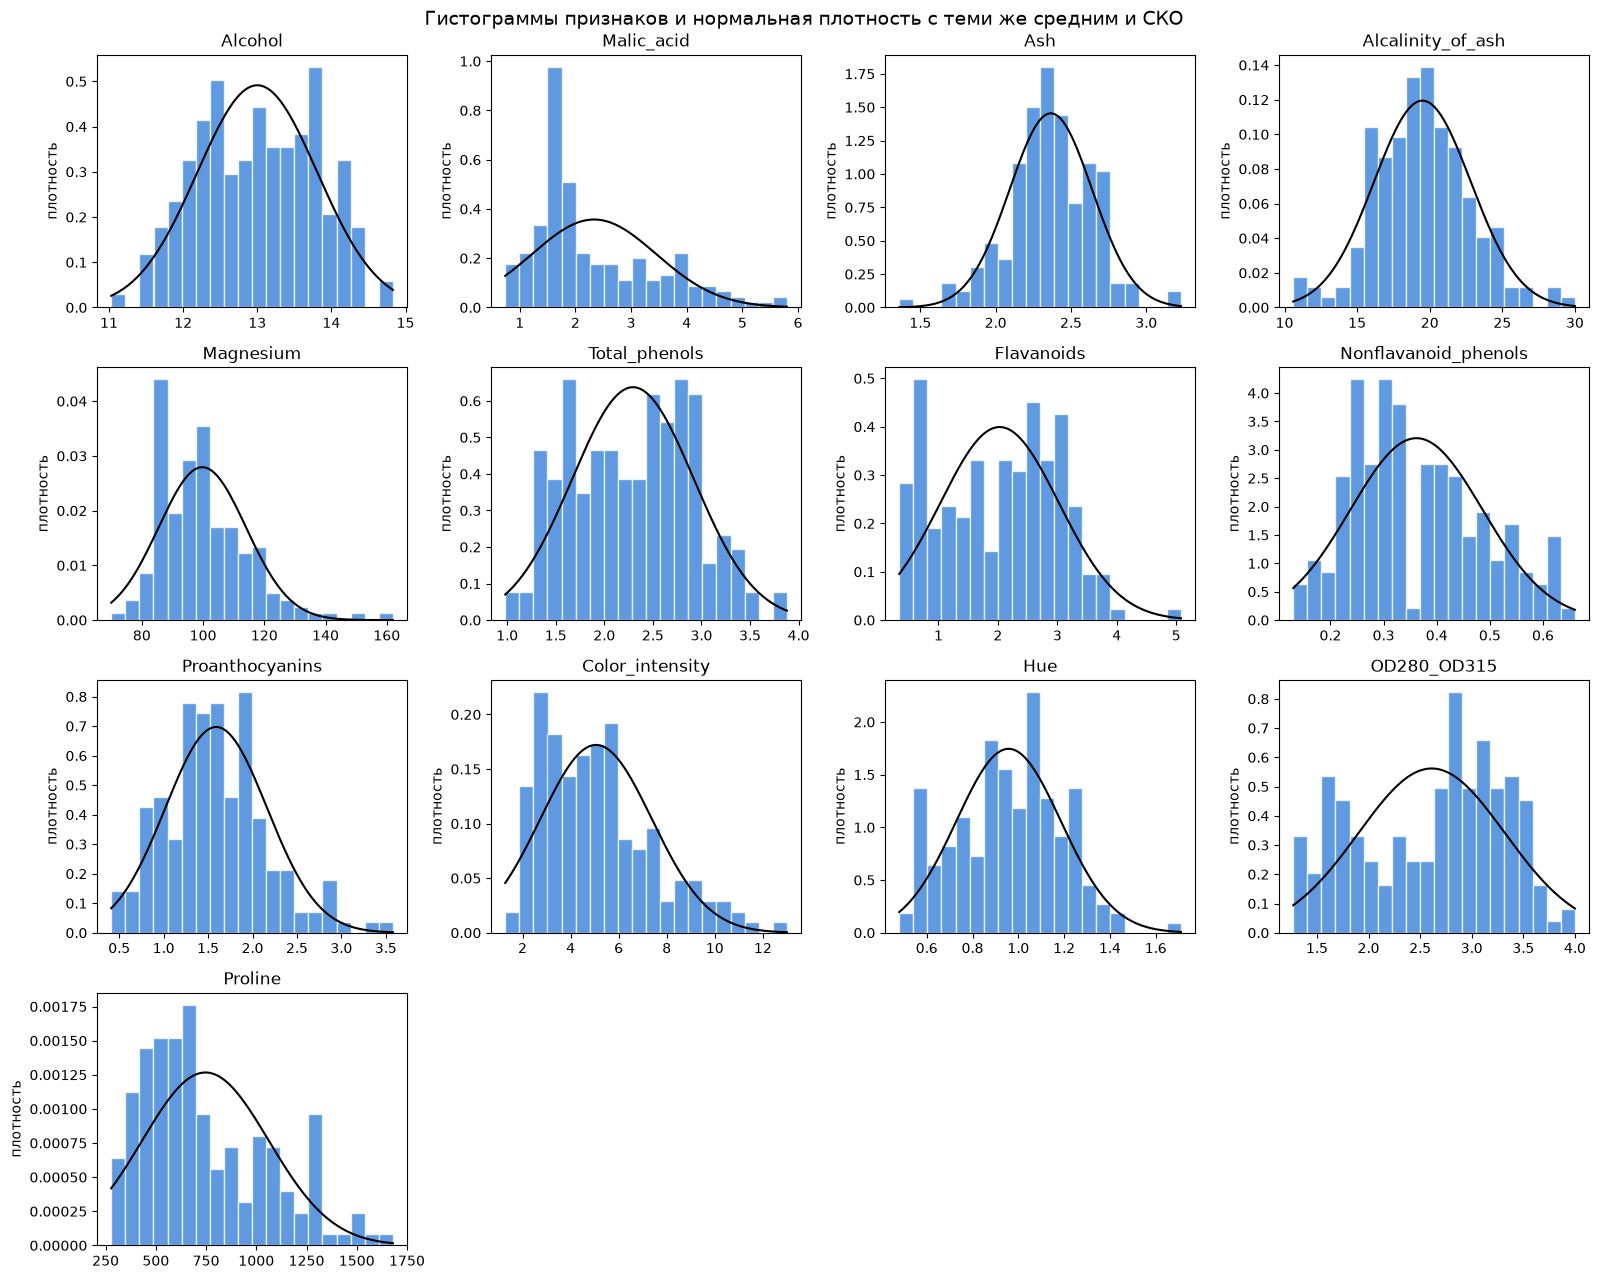

In [5]:
fig, axes = plt.subplots(4, 4, figsize=(16, 13))
for ax, col in zip(axes.flat, X.columns):
    ax.hist(X[col], bins=20, density=True, color=COLORS[0], alpha=0.75, edgecolor='white')
    grid = np.linspace(X[col].min(), X[col].max(), 200)
    ax.plot(grid, stats.norm.pdf(grid, X[col].mean(), X[col].std()), color='black', lw=1.5)
    ax.set_title(col)
    ax.set_ylabel('плотность')
for ax in axes.flat[len(X.columns):]:
    ax.axis('off')
fig.suptitle('Гистограммы признаков и нормальная плотность с теми же средним и СКО', fontsize=14)
fig.tight_layout()
fig.savefig('Рисунки/гистограммы.png', dpi=200, bbox_inches='tight')
plt.show()

Форма распределений разная. Ближе всего к нормальной кривой Alcalinity_of_ash и Ash (у Ash — отдельные значения
на обоих краях). Malic_acid, Magnesium, Color_intensity и Proline скошены вправо: основная масса значений слева и
длинный «хвост» больших значений. У Flavanoids, OD280_OD315 и Total_phenols по два скопления значений (у Flavanoids —
около 0,5–1 и около 2,5–3, у OD280_OD315 — около 1,5–2 и около 3), у Alcohol — широкая плоская вершина. Распределение
с двумя максимумами получается, например, при смешении двух групп с далёкими средними, поэтому такие гистограммы
согласуются с наличием групп в данных.

Количественная проверка: коэффициент асимметрии (у нормального распределения 0), коэффициент эксцесса
(pandas считает избыточный эксцесс, у нормального распределения 0) и тест Шапиро–Уилка. Нулевая гипотеза теста —
«выборка из нормального распределения»; при p-значении меньше 0,05 она отвергается.

In [6]:
rows = []
for col in X.columns:
    w, p = stats.shapiro(X[col])
    rows.append({'признак': col, 'асимметрия': X[col].skew(), 'эксцесс': X[col].kurt(),
                 'W Шапиро–Уилка': w, 'p-значение': p})
normality = pd.DataFrame(rows).set_index('признак')
normality['нормальность при α = 0,05'] = np.where(normality['p-значение'] > 0.05, 'не отвергается', 'отвергается')
display(normality.round(4))
normality.to_csv('Результаты/нормальность.csv', encoding='utf-8')

,асимметрия,эксцесс,W Шапиро–Уилка,p-значение,"нормальность при α = 0,05"
признак,,,,,
Alcohol,-0.0515,-0.8525,0.9818,0.0200,отвергается
Malic_acid,1.0397,0.2992,0.8888,0.0000,отвергается
Ash,-0.1767,1.1440,0.9839,0.0387,отвергается
Alcalinity_of_ash,0.2130,0.4879,0.9902,0.2639,не отвергается
Magnesium,1.0982,2.1050,0.9383,0.0000,отвергается
Total_phenols,0.0866,-0.8356,0.9767,0.0044,отвергается
Flavanoids,0.0253,-0.8804,0.9545,0.0000,отвергается
Nonflavanoid_phenols,0.4502,-0.6372,0.9625,0.0001,отвергается
Proanthocyanins,0.5171,0.5546,0.9807,0.0145,отвергается


При уровне значимости 0,05 гипотеза о нормальности отвергается для 12 из 13 признаков и не отвергается только для
Alcalinity_of_ash (W = 0,990, p = 0,264). Сильнее всего от нормального отличаются Malic_acid (W = 0,889, асимметрия
1,04), Proline (W = 0,931, асимметрия 0,77), Magnesium (W = 0,938, асимметрия 1,10, эксцесс 2,105 — тяжёлый правый
хвост) и Color_intensity (W = 0,940, асимметрия 0,87). Отрицательный эксцесс, то есть более плоская, чем у
нормального распределения, вершина, — у OD280_OD315 (−1,09), Flavanoids (−0,88), Alcohol (−0,85) и Total_phenols
(−0,84), как и видно на гистограммах. У Ash асимметрии почти нет (−0,18), но эксцесс 1,14: крайние значения 1,36 и
3,23 удалены от среднего 2,37 больше чем на три стандартных отклонения, и тест отвергает нормальность (p = 0,039).

Для кластеризации нормальность признаков не обязательна: K-means и метод Уорда минимизируют сумму квадратов
расстояний и не используют предположений о виде распределения. Но квадраты расстояний чувствительны к длинным
хвостам и выбросам, поэтому выбросы проверяются отдельно (п. 1.5 и 3.4).

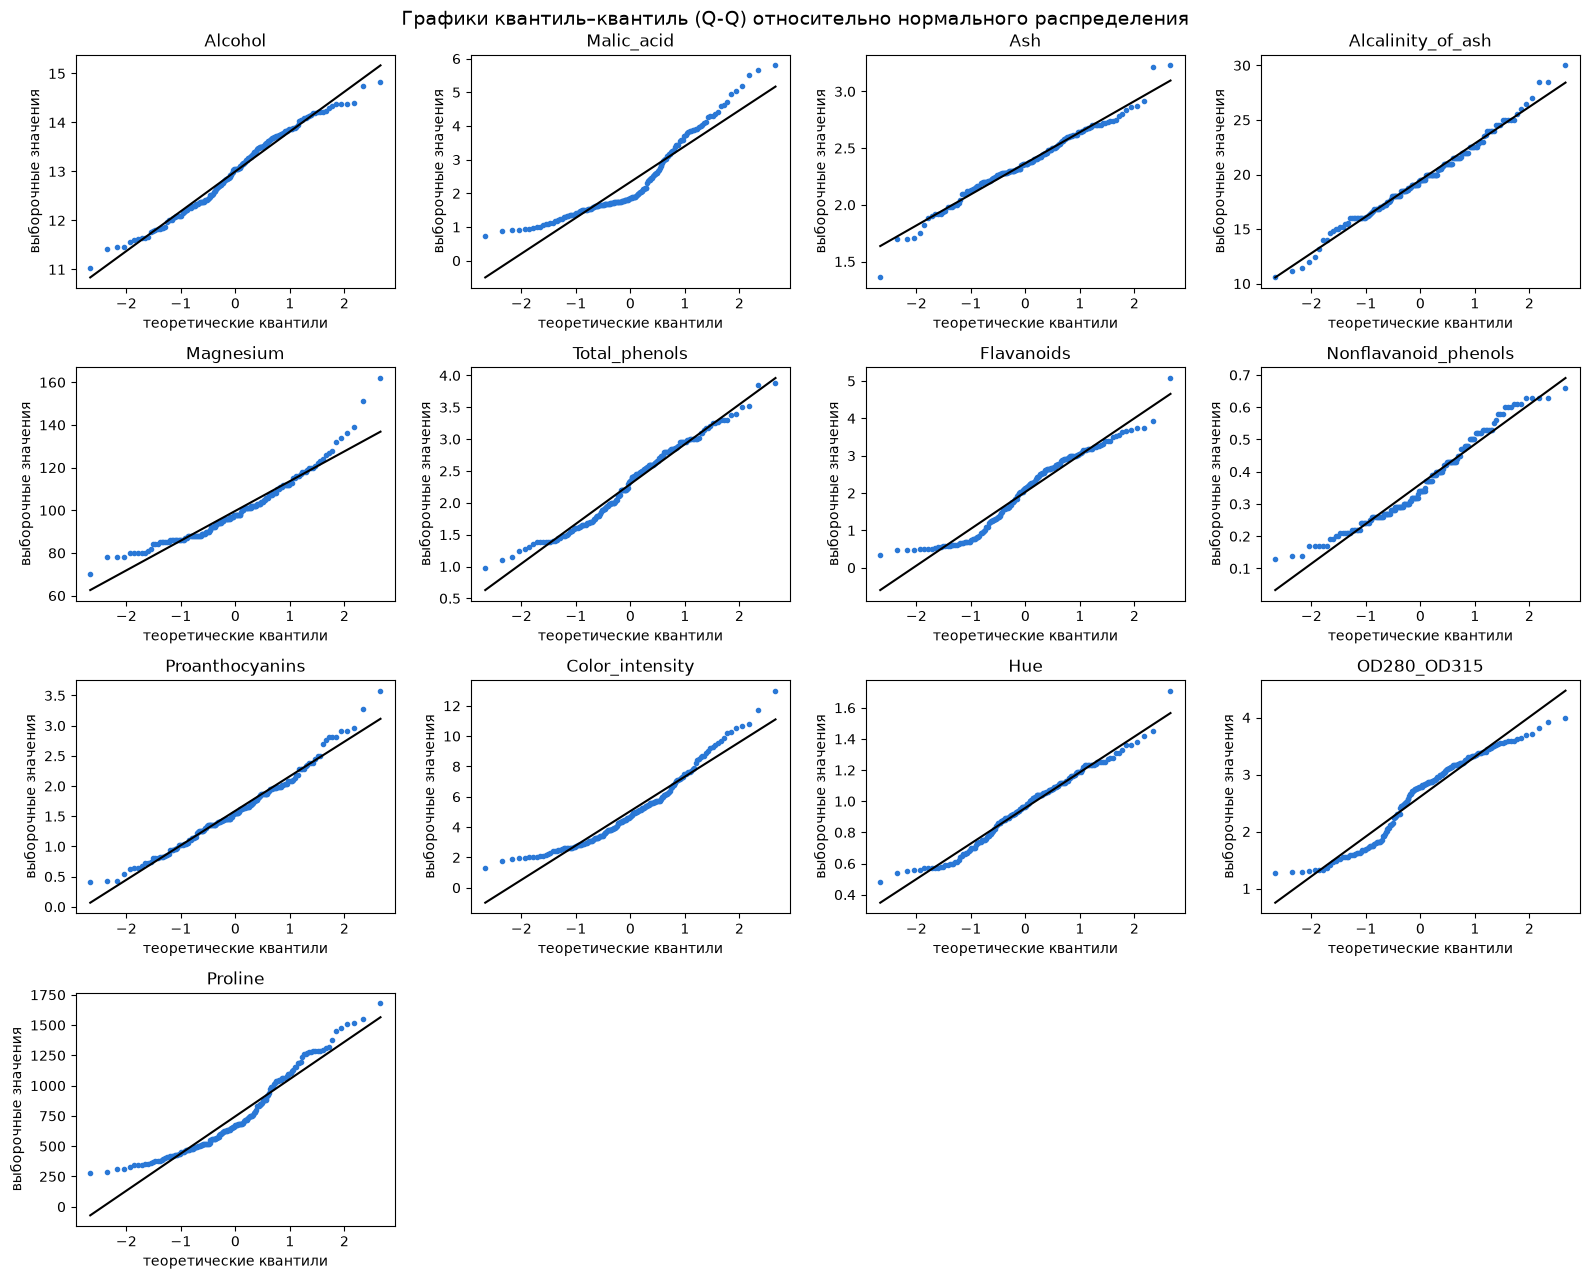

In [7]:
fig, axes = plt.subplots(4, 4, figsize=(16, 13))
for ax, col in zip(axes.flat, X.columns):
    stats.probplot(X[col], dist='norm', plot=ax)
    points, line = ax.get_lines()
    points.set(color=COLORS[0], markersize=3)
    line.set_color('black')
    ax.set_title(col)
    ax.set_xlabel('теоретические квантили')
    ax.set_ylabel('выборочные значения')
for ax in axes.flat[len(X.columns):]:
    ax.axis('off')
fig.suptitle('Графики квантиль–квантиль (Q-Q) относительно нормального распределения', fontsize=14)
fig.tight_layout()
fig.savefig('Рисунки/qq_графики.png', dpi=200, bbox_inches='tight')
plt.show()

Если признак распределён нормально, точки на графике Q-Q лежат на прямой. Ближе всего к прямой Alcalinity_of_ash и
Ash (кроме крайних точек), а также Hue и Proanthocyanins (кроме правого края). У Malic_acid, Magnesium,
Color_intensity и Proline точки на обоих концах лежат выше прямой, а в середине — ниже: так выглядит правосторонняя
асимметрия, большие значения у этих признаков больше, чем были бы при нормальном распределении. У Flavanoids и
OD280_OD315 кривая S-образная, со «ступенькой»: значения сгущаются в двух местах, что соответствует двум максимумам
на гистограммах.

### 1.4. Информационная значимость признаков
После стандартизации дисперсия любого признака равна 1, поэтому «разброс» в стандартизованных единицах ничего
не говорит об информативности. Использованы показатели, не требующие метки сорта:
- коэффициент вариации CV (относительный разброс на исходной шкале);
- корреляционная матрица: сильно коррелирующие признаки частично дублируют друг друга;
- связь с главными компонентами: корреляции признака с PC1 и PC2 и доля дисперсии признака, которую сохраняет
  плоскость PC1–PC2 (сумма квадратов этих корреляций). Признаки с большой долей формируют главную структуру данных.

Справочно (только для проверки, в кластеризации метка не используется) приведены F-статистика однофакторного
дисперсионного анализа по сортам и взаимная информация признака с сортом.

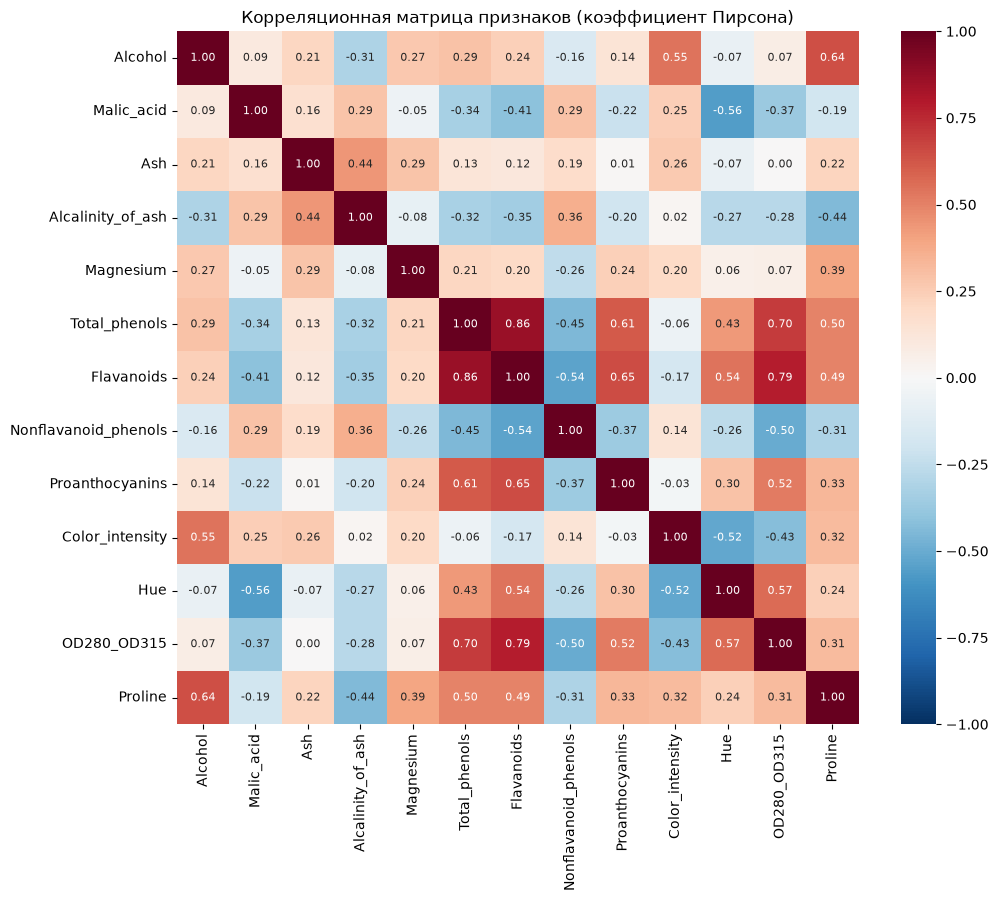

,,r
Total_phenols,Flavanoids,0.865
Flavanoids,OD280_OD315,0.787
Total_phenols,OD280_OD315,0.700
Flavanoids,Proanthocyanins,0.653
Alcohol,Proline,0.644
Total_phenols,Proanthocyanins,0.612


In [8]:
corr = X.corr()
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1, annot_kws={'size': 8}, ax=ax)
ax.set_title('Корреляционная матрица признаков (коэффициент Пирсона)')
fig.savefig('Рисунки/корреляции.png', dpi=200, bbox_inches='tight')
plt.show()
pairs = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1)).stack()
strong = pairs[pairs.abs() >= 0.6].sort_values(key=abs, ascending=False).to_frame('r')
display(strong.round(3))
strong.to_csv('Результаты/сильные_корреляции.csv', encoding='utf-8')

Самые сильные положительные связи — внутри группы Total_phenols, Flavanoids, OD280_OD315 и Proanthocyanins:
r(Total_phenols, Flavanoids) = 0,865, r(Flavanoids, OD280_OD315) = 0,787, r(Total_phenols, OD280_OD315) = 0,700,
r(Flavanoids, Proanthocyanins) = 0,653, r(Total_phenols, Proanthocyanins) = 0,612; кроме того, связаны Alcohol и
Proline (0,644). Наиболее заметные отрицательные связи на тепловой карте: Malic_acid и Hue (−0,56), Flavanoids и
Nonflavanoid_phenols (−0,54), Color_intensity и Hue (−0,52). Сильно коррелирующие признаки частично дублируют друг
друга: общее для них направление разброса входит в евклидово расстояние несколько раз. Признаки всё же не удаляются:
даже для самой сильной пары общая доля дисперсии $r^2 = 0{,}865^2 \approx 0{,}75$, то есть четверть разброса каждого
признака своя.

In [9]:
X_std = StandardScaler().fit_transform(X)
pca_info = PCA().fit(X_std)
scores = pd.DataFrame(pca_info.transform(X_std)[:, :2], columns=['PC1', 'PC2'])
r_pc = pd.concat([X, scores], axis=1).corr().loc[X.columns, ['PC1', 'PC2']]
F_stat, _ = f_classif(X, y_true)
informativeness = pd.DataFrame({
    'CV': desc['CV'],
    'макс. |r| с другими': (corr.abs() - np.eye(len(corr))).max(),
    'r с PC1': r_pc['PC1'],
    'r с PC2': r_pc['PC2'],
    'доля дисперсии на PC1–PC2': r_pc['PC1'] ** 2 + r_pc['PC2'] ** 2,
    'F по сортам (справочно)': F_stat,
    'MI с сортом (справочно)': mutual_info_classif(X, y_true, random_state=RANDOM_STATE),
}).sort_values('доля дисперсии на PC1–PC2', ascending=False)
display(informativeness.round(3))
informativeness.to_csv('Результаты/информативность.csv', encoding='utf-8')
print('Доля общей дисперсии, объяснённая PC1 и PC2:', pca_info.explained_variance_ratio_[:2].round(4))

,CV,макс. |r| с другими,r с PC1,r с PC2,доля дисперсии на PC1–PC2,F по сортам (справочно),MI с сортом (справочно)
Flavanoids,0.492,0.865,0.917,-0.005,0.842,233.926,0.668
Total_phenols,0.273,0.865,0.856,0.103,0.744,93.733,0.402
Color_intensity,0.458,0.546,-0.192,0.837,0.738,120.664,0.548
OD280_OD315,0.272,0.787,0.816,-0.260,0.733,189.972,0.516
Proline,0.422,0.644,0.622,0.577,0.719,207.920,0.577
Alcohol,0.062,0.644,0.313,0.764,0.682,135.078,0.474
Hue,0.239,0.565,0.644,-0.441,0.609,101.317,0.466
Proanthocyanins,0.360,0.653,0.680,0.062,0.466,30.271,0.305
Nonflavanoid_phenols,0.344,0.538,-0.648,0.045,0.421,27.575,0.121
Malic_acid,0.478,0.561,-0.532,0.355,0.409,36.943,0.282


Доля общей дисперсии, объяснённая PC1 и PC2: [0.362  0.1921]


Первые две главные компоненты объясняют 36,2 % и 19,2 % общей дисперсии. С PC1 сильнее всего связаны Flavanoids
(r = 0,917), Total_phenols (0,856), OD280_OD315 (0,816), Proanthocyanins (0,680), Hue (0,644) и с обратным знаком
Nonflavanoid_phenols (−0,648), Malic_acid (−0,532) и Alcalinity_of_ash (−0,519). С PC2 — Color_intensity (0,837),
Alcohol (0,764), Proline (0,577), Ash (0,499) и Magnesium (0,473). Наибольшая доля дисперсии на плоскости PC1–PC2 —
у Flavanoids (0,842), Total_phenols (0,744), Color_intensity (0,738), OD280_OD315 (0,733), Proline (0,719) и Alcohol
(0,682): эти признаки задают главную структуру данных. Хуже всего представлены Ash (0,249), Alcalinity_of_ash
(0,270) и Magnesium (0,319): основная часть их дисперсии приходится на следующие компоненты. Коэффициент вариации
даёт другой порядок (у Alcohol он наименьший, 0,062, хотя Alcohol хорошо представлен на PC2): относительный разброс
сам по себе не показывает, разделяет ли признак группы объектов.

Справочная F-статистика по сортам наибольшая у Flavanoids (233,9), Proline (207,9), OD280_OD315 (190,0), Alcohol
(135,1) и Color_intensity (120,7), наименьшая — у Magnesium (12,4) и Ash (13,3); взаимная информация упорядочивает
признаки похоже (Flavanoids 0,668, Proline 0,577, Color_intensity 0,548). Оценка без метки и справочная оценка по
сортам выделяют в основном одни и те же признаки. Для кластеризации оставлены все 13 признаков: отбор по
F-статистике использовал бы метку сорта, а без метки нет оснований считать какой-либо признак лишним.

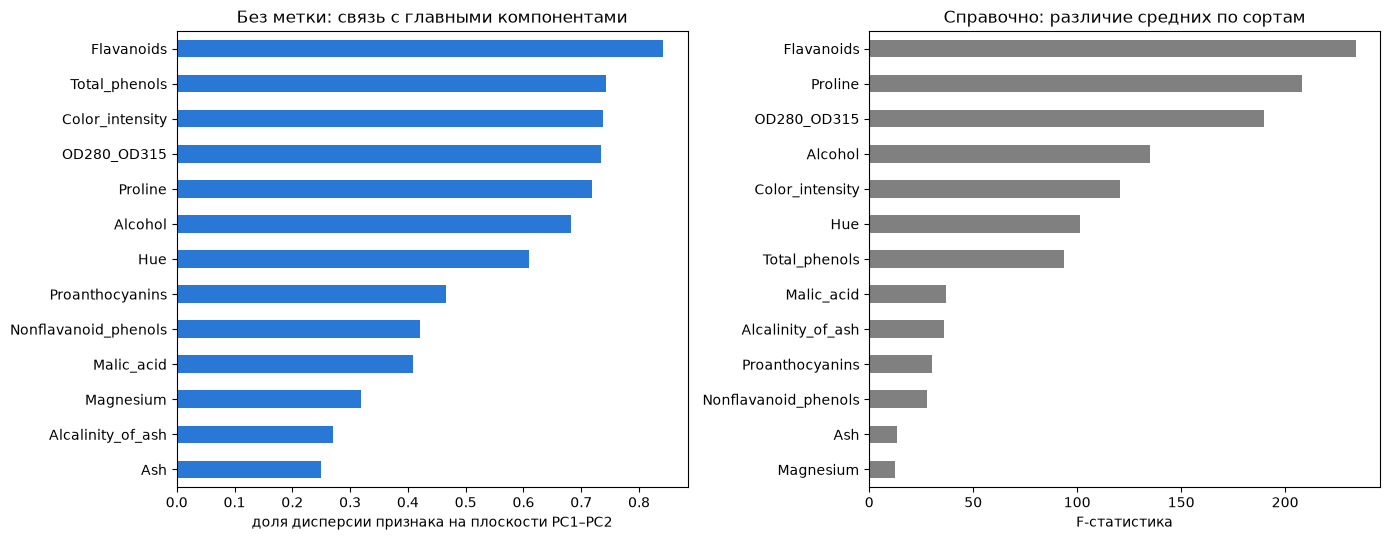

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
informativeness['доля дисперсии на PC1–PC2'].plot.barh(ax=axes[0], color=COLORS[0])
axes[0].invert_yaxis()
axes[0].set_xlabel('доля дисперсии признака на плоскости PC1–PC2')
axes[0].set_title('Без метки: связь с главными компонентами')
informativeness['F по сортам (справочно)'].sort_values().plot.barh(ax=axes[1], color='gray')
axes[1].set_xlabel('F-статистика')
axes[1].set_title('Справочно: различие средних по сортам')
fig.tight_layout()
fig.savefig('Рисунки/информативность.png', dpi=200, bbox_inches='tight')
plt.show()

Слева признаки упорядочены по доле дисперсии на плоскости PC1–PC2 (без метки), справа — по справочной
F-статистике. Шесть верхних признаков слева (Flavanoids, Total_phenols, Color_intensity, OD280_OD315, Proline,
Alcohol) входят в семь верхних справа; заметно различаются места только у Total_phenols (слева второе, справа
седьмое) и Hue (слева седьмое, справа шестое). Эти шесть признаков взяты для матрицы диаграмм рассеяния в п. 2.2.

### 1.5. Выбросы
Два правила: межквартильный размах (выброс — значение вне $[Q_1 - 1{,}5\,IQR;\ Q_3 + 1{,}5\,IQR]$) и z-оценка
(выброс — $|z| > 3$, где $z = (x - \bar{x})/s$).

In [11]:
q1, q3 = X.quantile(0.25), X.quantile(0.75)
iqr = q3 - q1
out_iqr = (X < q1 - 1.5 * iqr) | (X > q3 + 1.5 * iqr)
z = (X - X.mean()) / X.std()
out_z = z.abs() > 3
outliers = pd.DataFrame({'выбросов по IQR': out_iqr.sum(), 'выбросов |z| > 3': out_z.sum(),
                         'максимум |z|': z.abs().max()})
display(outliers.round(2))
outliers.to_csv('Результаты/выбросы.csv', encoding='utf-8')
print('Всего значений-выбросов: по IQR —', out_iqr.sum().sum(), ', по |z| > 3 —', out_z.sum().sum())
print('Объектов хотя бы с одним выбросом: по IQR —', out_iqr.any(axis=1).sum(),
      ', по |z| > 3 —', out_z.any(axis=1).sum())
print('Индексы строк с |z| > 3 (нумерация с 0):', list(X.index[out_z.any(axis=1)]))
summary['выбросы'] = {'значений_IQR': int(out_iqr.sum().sum()), 'значений_z': int(out_z.sum().sum()),
                      'объектов_IQR': int(out_iqr.any(axis=1).sum()), 'объектов_z': int(out_z.any(axis=1).sum()),
                      'индексы_z': [int(i) for i in X.index[out_z.any(axis=1)]]}

,выбросов по IQR,выбросов |z| > 3,максимум |z|
Alcohol,0,0,2.43
Malic_acid,3,1,3.10
Ash,3,3,3.67
Alcalinity_of_ash,4,1,3.15
Magnesium,4,2,4.36
Total_phenols,0,0,2.53
Flavanoids,0,1,3.05
Nonflavanoid_phenols,0,0,2.40
Proanthocyanins,2,1,3.48
Color_intensity,4,1,3.43


Всего значений-выбросов: по IQR — 21 , по |z| > 3 — 11
Объектов хотя бы с одним выбросом: по IQR — 17 , по |z| > 3 — 10
Индексы строк с |z| > 3 (нумерация с 0): [25, 59, 69, 73, 95, 110, 115, 121, 123, 158]


По правилу IQR найдено 21 значение-выброс у 7 признаков (больше всего — по 4 у Alcalinity_of_ash, Magnesium и
Color_intensity), они принадлежат 17 объектам. По правилу |z| > 3 — 11 значений у 10 объектов (индексы 25, 59, 69,
73, 95, 110, 115, 121, 123, 158). Самое большое отклонение — у Magnesium: |z| = 4,36 (значение 162 при среднем
99,7). У Alcohol, Total_phenols, Nonflavanoid_phenols, OD280_OD315 и Proline выбросов нет ни по одному правилу.

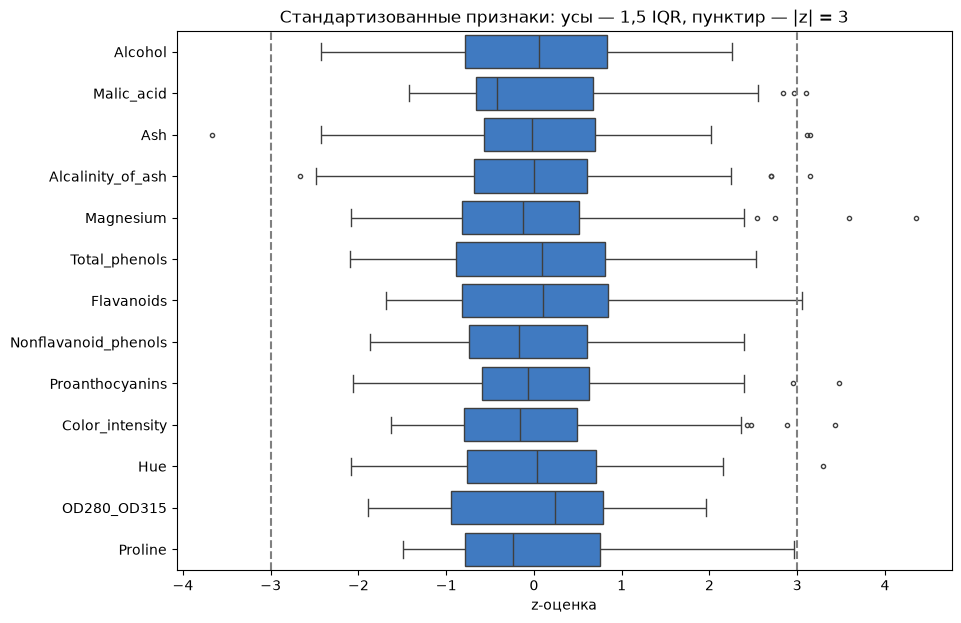

In [12]:
fig, ax = plt.subplots(figsize=(10, 7))
sns.boxplot(data=z, orient='h', color=COLORS[0], fliersize=3, ax=ax)
ax.axvline(3, color='gray', ls='--')
ax.axvline(-3, color='gray', ls='--')
ax.set_xlabel('z-оценка')
ax.set_title('Стандартизованные признаки: усы — 1,5 IQR, пунктир — |z| = 3')
fig.savefig('Рисунки/выбросы.png', dpi=200, bbox_inches='tight')
plt.show()

Точки за усами — выбросы по правилу IQR, за пунктиром — по правилу |z| > 3. Большинство выбросов — в правых хвостах
скошенных признаков (Magnesium, Color_intensity, Malic_acid, Proanthocyanins), у Ash и Alcalinity_of_ash — с обеих
сторон. Признаков ошибок записи нет: все значения положительные, нулей нет, наибольшее отклонение — 4,36
стандартного отклонения, а не на порядок.

**Решение:** объекты с выбросами не удаляются. Их немного (10 из 178 по правилу |z| > 3), задача — разбить на группы
все 178 образцов, а проверка в п. 3.4 показала, что удаление этих объектов почти не меняет разбиение (ARI = 0,981
для K-means и 0,931 для метода Уорда). Влияние выбросов на масштабирование уменьшено выбором стандартизации вместо
минимаксной нормализации (п. 2.1).

### 1.6. Условия применимости кластеризации
1. **Отсутствие классов.** Кластеризация выполняется только по 13 признакам `X`; метка сорта отделена при загрузке
   и используется лишь для внешних метрик и рисунков «для сравнения». Набор обрабатывается как данные без классов,
   а известное деление на сорта служит проверкой результата.
2. **Осмысленность кластеризации.** Все признаки — количественные результаты химического анализа одних и тех же
   объектов, поэтому после приведения к одному масштабу (раздел 2) расстояние между объектами означает различие
   химического состава. О наличии групп говорят два максимума у Flavanoids и OD280_OD315 (п. 1.3), облака точек на
   диаграммах рассеяния и в проекции PCA (раздел 2) и проверка перемешиванием (п. 3.4: средний силуэт 0,285 на
   настоящих данных против 0,067 на данных без структуры).
3. **Отсутствие выбросов.** Выбросы есть (10 объектов по |z| > 3, 17 по IQR), но они почти не меняют разбиение
   (п. 3.4), поэтому оставлены.

## 2. Масштабирование и визуальная оценка структуры

### 2.1. Стандартизация
K-means и метод Уорда сравнивают объекты по евклидову расстоянию
$d(x, x') = \sqrt{\sum_{j}(x_j - x'_j)^2}$, в котором каждый признак входит со своим масштабом. Признаки Wine
измерены в разных единицах и различаются по порядку величины, поэтому без масштабирования расстояние определяли бы
признаки с самыми большими числами. Выбрана стандартизация `StandardScaler`: $z = (x - \bar{x}) / s$ — после неё у
каждого признака среднее 0 и стандартное отклонение 1. Она использует среднее и стандартное отклонение, а не
минимум и максимум, поэтому единичные выбросы (п. 1.5) не сжимают остальные значения в узкий интервал, как при
минимаксной нормализации. Стандартизацию рекомендует и описание набора данных (`wine.names`), и задание.

In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
check = pd.DataFrame({'среднее после': X_scaled.mean(axis=0), 'СКО после': X_scaled.std(axis=0),
                      'дисперсия до': X.var(), 'доля в сумме дисперсий до': X.var() / X.var().sum()},
                     index=X.columns)
display(check.round(4) + 0.0)
summary['доля_Proline_в_дисперсии'] = round(float(check.loc['Proline', 'доля в сумме дисперсий до']), 6)

,среднее после,СКО после,дисперсия до,доля в сумме дисперсий до
Alcohol,0.0,1.0,0.6591,0.0000
Malic_acid,0.0,1.0,1.2480,0.0000
Ash,0.0,1.0,0.0753,0.0000
Alcalinity_of_ash,0.0,1.0,11.1527,0.0001
Magnesium,0.0,1.0,203.9893,0.0021
Total_phenols,0.0,1.0,0.3917,0.0000
Flavanoids,0.0,1.0,0.9977,0.0000
Nonflavanoid_phenols,0.0,1.0,0.0155,0.0000
Proanthocyanins,0.0,1.0,0.3276,0.0000
Color_intensity,0.0,1.0,5.3744,0.0001


После `StandardScaler` у всех признаков среднее 0 и стандартное отклонение 1. До масштабирования дисперсия Proline
была 99 166,7, Magnesium — 204,0, остальных признаков — от 0,0155 (Nonflavanoid_phenols) до 11,15
(Alcalinity_of_ash); на Proline приходилось 99,77 % суммы дисперсий. Средний квадрат разности двух объектов по
признаку равен удвоенной дисперсии признака, поэтому без масштабирования 99,77 % среднего квадрата евклидова
расстояния давал бы один Proline.

Что произошло бы без масштабирования: K-means с тремя кластерами (выбор k = 3 обоснован в разделе 3) на исходных
признаках сравнивается с K-means по одному признаку Proline. Метка сорта здесь используется только для проверки.

In [14]:
labels_raw = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE).fit_predict(X)
labels_proline = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE).fit_predict(X[['Proline']])
labels_std = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE).fit_predict(X_scaled)
print('ARI(без масштабирования, только Proline):', round(adjusted_rand_score(labels_raw, labels_proline), 4))
print('ARI с сортами без масштабирования:', round(adjusted_rand_score(y_true, labels_raw), 4))
print('ARI с сортами после стандартизации:', round(adjusted_rand_score(y_true, labels_std), 4))
summary['ARI_без_масштабирования'] = round(adjusted_rand_score(y_true, labels_raw), 6)
summary['ARI_исходные_и_Proline'] = round(adjusted_rand_score(labels_raw, labels_proline), 6)

ARI(без масштабирования, только Proline): 1.0
ARI с сортами без масштабирования: 0.3711
ARI с сортами после стандартизации: 0.8975


Без масштабирования разбиение K-means совпало с разбиением по одному признаку Proline (ARI = 1,0): остальные 12
признаков на результат не повлияли. Справочно: согласие с сортами без масштабирования ARI = 0,371, после
стандартизации — 0,897. Это подтверждает необходимость стандартизации; далее все методы работают со
стандартизованными признаками `X_scaled`.

### 2.2. Матрица диаграмм рассеяния
Чтобы матрица была читаемой, взяты шесть признаков с наибольшей долей дисперсии на плоскости PC1–PC2 (п. 1.4) —
они сильнее всего участвуют в главной структуре данных. Точки не раскрашены: при кластеризации метка неизвестна.

Признаки для матрицы: ['Flavanoids', 'Total_phenols', 'Color_intensity', 'OD280_OD315', 'Proline', 'Alcohol']


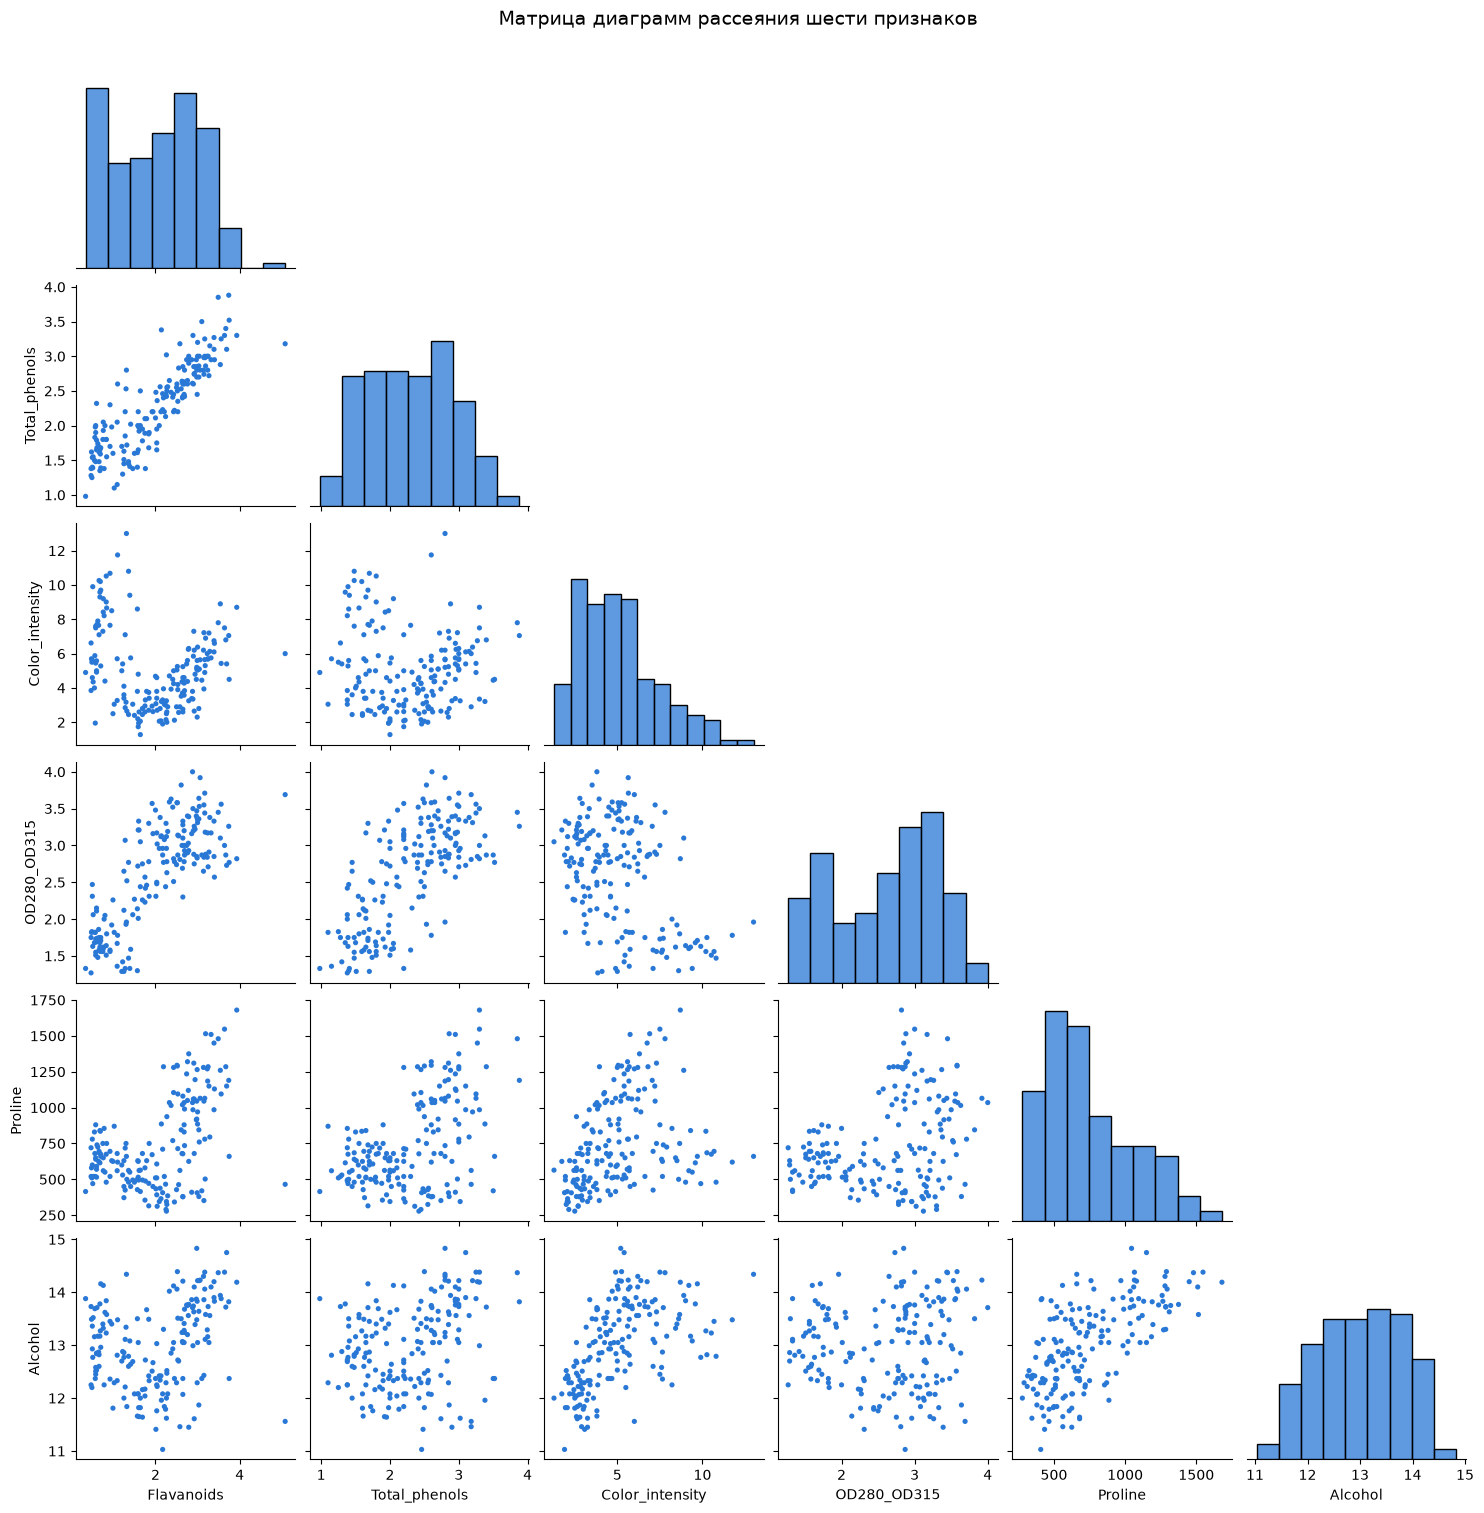

In [15]:
top6 = informativeness.index[:6].tolist()
print('Признаки для матрицы:', top6)
pair_grid = sns.pairplot(X[top6], corner=True, diag_kind='hist',
                         plot_kws={'s': 14, 'color': COLORS[0], 'edgecolor': 'none'},
                         diag_kws={'color': COLORS[0]})
pair_grid.figure.suptitle('Матрица диаграмм рассеяния шести признаков', y=1.01, fontsize=14)
pair_grid.savefig('Рисунки/матрица_рассеяния.png', dpi=200, bbox_inches='tight')
plt.show()

На диаграммах рассеяния видны группы точек. Отчётливее всего — на паре Flavanoids – Color_intensity: три облака —
малые Flavanoids (примерно 0,3–1,5) при высокой Color_intensity (примерно 4–13), средние Flavanoids (1–3) при низкой
Color_intensity (примерно 1,5–4) и высокие Flavanoids (около 2,5–4) при средней Color_intensity (примерно 3,5–9).
Похожие три облака — на паре OD280_OD315 – Color_intensity, а на парах с Proline сверху отделяется облако с Proline
выше примерно 900. Total_phenols и Flavanoids связаны почти линейно (r = 0,865), и на этой паре облака сливаются.
Облака компактные, примерно эллиптические и сравнимого размера; групп сложной формы (колец, изогнутых лент) не
видно. Предположительное число кластеров — три.

### 2.3. Проекция на две главные компоненты
Метод главных компонент находит ортогональные направления наибольшей дисперсии; проекция на первые две компоненты
показывает все 13 признаков сразу (с потерей части дисперсии).

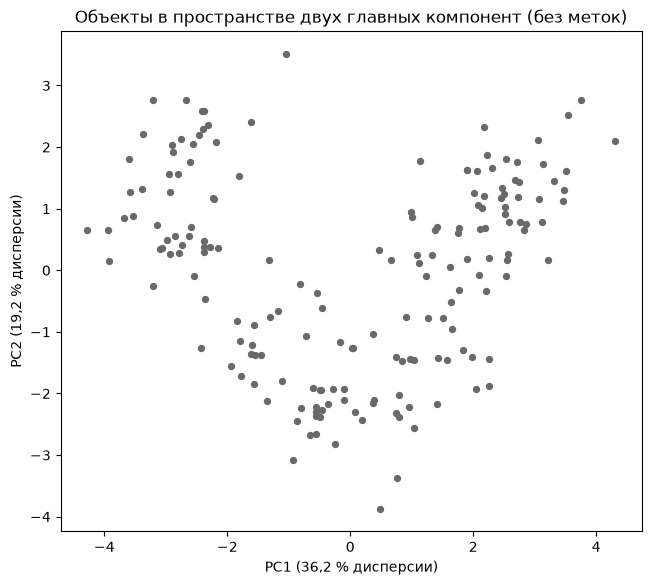

Доли объяснённой дисперсии PC1, PC2: [0.362  0.1921] ; вместе: 0.5541


In [16]:
pca = PCA(n_components=2).fit(X_scaled)
X_pca = pca.transform(X_scaled)
evr = pca.explained_variance_ratio_
fig, ax = plt.subplots(figsize=(7.5, 6.5))
ax.scatter(X_pca[:, 0], X_pca[:, 1], s=18, color='dimgray')
ax.set_xlabel(f'PC1 ({100 * evr[0]:.1f} % дисперсии)'.replace('.', ','))
ax.set_ylabel(f'PC2 ({100 * evr[1]:.1f} % дисперсии)'.replace('.', ','))
ax.set_title('Объекты в пространстве двух главных компонент (без меток)')
fig.savefig('Рисунки/pca_без_меток.png', dpi=200, bbox_inches='tight')
plt.show()
print('Доли объяснённой дисперсии PC1, PC2:', evr.round(4), '; вместе:', round(evr.sum(), 4))
summary['PCA_доли'] = [round(float(v), 6) for v in evr]

Первые две главные компоненты сохраняют 55,4 % общей дисперсии (36,2 % и 19,2 %). Объекты располагаются дугой с
тремя сгущениями — слева, внизу и справа; между нижним сгущением и двумя другими есть переходные точки, поэтому
границы групп нечёткие. Сгущения компактные, примерно одного размера и похожей плотности и не разделены пустыми
промежутками. Это согласуется с предположением о трёх кластерах (число кластеров подбирается в разделе 3).

### 2.4. Выбор методов кластеризации
По п. 2.2–2.3 структура данных — три компактные выпуклые группы примерно одинакового размера и плотности, не
разделённые пустыми областями. Из четырёх методов задания:
- **K-means** ищет k компактных групп вокруг центров, минимизируя внутрикластерную сумму квадратов; он рассчитан на
  выпуклые кластеры близкого размера — именно такие видны на рисунках;
- **иерархическая агломеративная кластеризация методом Уорда** на каждом шаге минимизирует прирост той же суммы
  квадратов, поэтому тоже ориентирована на компактные группы, но не требует заранее задавать k: дендрограмма
  показывает всю иерархию слияний и помогает выбрать число кластеров, а результат не зависит от случайной
  инициализации;
- **DBSCAN** выделяет кластеры как области высокой плотности, разделённые областями низкой плотности, и подходит для
  кластеров произвольной формы и данных с шумом. Здесь пустых промежутков между группами нет, поэтому применимость
  DBSCAN сомнительна — это проверено в п. 5.2;
- **EM-алгоритм (Gaussian Mixture)** описывает данные смесью нормальных распределений; при полных ковариационных
  матрицах для трёх компонент в 13 признаках нужно оценить 3 × 91 = 273 параметра ковариаций по 178 объектам,
  поэтому он использован только для сравнения (п. 7.5) с упрощённой формой ковариаций.

Основные методы работы — K-means и метод Уорда.

## 3. Кластеризация методами K-means и иерархической агломеративной (Уорда)

Номера кластеров, которые выдаёт алгоритм, произвольны. Чтобы разбиения разных методов было удобно сравнивать,
кластеры перенумерованы: 1, 2, 3, … в порядке убывания средней координаты объектов на PC1. На метрики это не
влияет — все они не зависят от перестановки номеров.

In [17]:
def relabel_by_pc1(labels):
    order = pd.Series(X_pca[:, 0]).groupby(labels).mean().sort_values(ascending=False).index
    return pd.Series(labels).map({old: new for new, old in enumerate(order, start=1)}).to_numpy()

### 3.1. K-means: метод локтя и анализ силуэта
Инерция (WCSS) — сумма квадратов расстояний объектов до центров своих кластеров; с ростом k она уменьшается,
а «локоть» — значение k, после которого убывание резко замедляется. Силуэт объекта
$s(i) = \dfrac{b(i) - a(i)}{\max(a(i), b(i))}$, где $a(i)$ — среднее расстояние до объектов своего кластера,
$b(i)$ — среднее расстояние до объектов ближайшего чужого кластера; средний силуэт ближе к 1 — кластеры компактнее
и лучше отделены. По рекомендации задания K-means запускается из 10 начальных положений центров (`n_init=10`).

In [18]:
ks = range(1, 11)
rows = []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_scaled)
    row = {'k': k, 'инерция (WCSS)': km.inertia_}
    if k > 1:
        row['силуэт'] = silhouette_score(X_scaled, km.labels_)
    rows.append(row)
k_table = pd.DataFrame(rows).set_index('k')
k_table['уменьшение инерции'] = -k_table['инерция (WCSS)'].diff()
display(k_table.round(4))
k_table.to_csv('Результаты/kmeans_локоть_силуэт.csv', encoding='utf-8')
k_best = int(k_table['силуэт'].idxmax())
print('Число кластеров с наибольшим силуэтом:', k_best)
summary['k_best'] = k_best

,инерция (WCSS),силуэт,уменьшение инерции
k,,,
1,2314.0000,NaN,NaN
2,1658.7589,0.2593,655.2411
3,1277.9285,0.2849,380.8304
4,1175.4283,0.2602,102.5002
5,1109.5127,0.2016,65.9156
6,1046.0023,0.2372,63.5104
7,981.5952,0.2036,64.4071
8,935.2012,0.1570,46.3940
9,889.8929,0.1499,45.3083


Число кластеров с наибольшим силуэтом: 3


Инерция с ростом k уменьшается, но по-разному: переход от одного кластера к двум уменьшает её на 655,2,
от двух к трём — на 380,8, от трёх к четырём — только на 102,5, дальше — на 44–66 за шаг. Средний силуэт наибольший
при k = 3 (0,285); при k = 2 он равен 0,259, при k = 4 — 0,260.

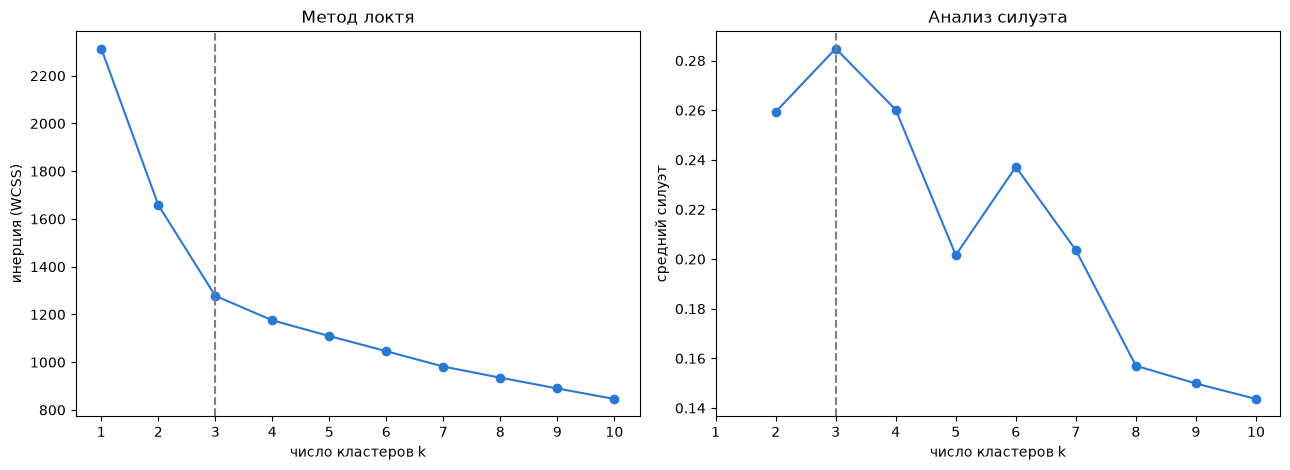

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].plot(k_table.index, k_table['инерция (WCSS)'], 'o-', color=COLORS[0])
axes[0].axvline(k_best, color='gray', ls='--')
axes[0].set_xlabel('число кластеров k')
axes[0].set_ylabel('инерция (WCSS)')
axes[0].set_title('Метод локтя')
axes[1].plot(k_table.index, k_table['силуэт'], 'o-', color=COLORS[0])
axes[1].axvline(k_best, color='gray', ls='--')
axes[1].set_xlabel('число кластеров k')
axes[1].set_ylabel('средний силуэт')
axes[1].set_title('Анализ силуэта')
for ax in axes:
    ax.set_xticks(list(ks))
fig.tight_layout()
fig.savefig('Рисунки/локоть_силуэт.png', dpi=200, bbox_inches='tight')
plt.show()

На графике локтя излом при k = 3: до него кривая падает круто, после — полого и почти линейно. Пик силуэта —
тоже при k = 3. Метод локтя и анализ силуэта указывают на одно и то же число кластеров, поэтому выбрано k = 3.
Второй, меньший пик силуэта при k = 6 (0,237) ниже, чем при k = 3, и при k = 6 появляется кластер всего из
5 объектов (п. 5.1).

### 3.2. K-means при выбранном k и силуэтная диаграмма

Итераций до сходимости: 7 ; инерция: 1277.93
Размеры кластеров: {1: 62, 2: 65, 3: 51}


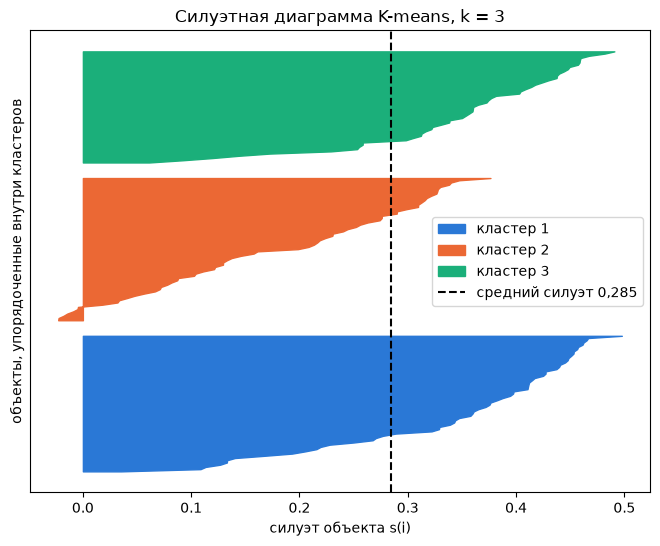

,средний силуэт,объектов с s < 0
кластер,,
1,0.343,0
2,0.177,7
3,0.351,0


In [20]:
kmeans = KMeans(n_clusters=k_best, n_init=10, random_state=RANDOM_STATE).fit(X_scaled)
labels_km = relabel_by_pc1(kmeans.labels_)
print('Итераций до сходимости:', kmeans.n_iter_, '; инерция:', round(kmeans.inertia_, 2))
print('Размеры кластеров:', pd.Series(labels_km).value_counts().sort_index().to_dict())

sil_values = silhouette_samples(X_scaled, labels_km)
fig, ax = plt.subplots(figsize=(8, 6))
y_low = 0
for c in range(1, k_best + 1):
    vals = np.sort(sil_values[labels_km == c])
    ax.fill_betweenx(np.arange(y_low, y_low + len(vals)), 0, vals, color=COLORS[c - 1], label=f'кластер {c}')
    y_low += len(vals) + 6
ax.axvline(sil_values.mean(), color='black', ls='--', label=f'средний силуэт {sil_values.mean():.3f}'.replace('.', ','))
ax.set_xlabel('силуэт объекта s(i)')
ax.set_ylabel('объекты, упорядоченные внутри кластеров')
ax.set_yticks([])
ax.set_title(f'Силуэтная диаграмма K-means, k = {k_best}')
ax.legend()
fig.savefig('Рисунки/силуэтная_диаграмма.png', dpi=200, bbox_inches='tight')
plt.show()
sil_by_cluster = pd.DataFrame({'кластер': labels_km, 's': sil_values}).groupby('кластер')['s']
sil_table = pd.DataFrame({'средний силуэт': sil_by_cluster.mean(),
                          'объектов с s < 0': sil_by_cluster.apply(lambda s: (s < 0).sum())})
display(sil_table.round(3))
sil_table.to_csv('Результаты/силуэт_по_кластерам.csv', encoding='utf-8')
summary['kmeans_итераций'] = int(kmeans.n_iter_)

K-means сошёлся за 7 итераций, инерция 1277,93; размеры кластеров — 62, 65 и 51 объект. Средний силуэт 0,285
положительный, но далёк от 1: кластеры отделены друг от друга, однако объекты на их границах находятся почти на
одинаковом расстоянии от своего и соседнего кластеров. Кластеры 1 и 3 плотные и хорошо отделены (средний силуэт
0,343 и 0,351, отрицательных значений нет). Кластер 2 слабее (0,177), у 7 его объектов силуэт отрицательный — в
среднем они ближе к объектам соседнего кластера, чем к своим. На проекции PCA (п. 6.1) кластер 2 — нижняя группа,
которая соприкасается с двумя другими.

### 3.3. Иерархическая агломеративная кластеризация (метод Уорда)
Алгоритм начинает с 178 кластеров из одного объекта и на каждом шаге объединяет два кластера, слияние которых
меньше всего увеличивает внутрикластерную сумму квадратов (критерий Уорда). Дендрограмма показывает всю
последовательность слияний; высота слияния в `scipy` для метода Уорда равна $\sqrt{2\,\Delta WCSS}$. Число кластеров
выбирается по наибольшему скачку высоты: дерево разрезается ниже этого слияния.

In [21]:
Z = linkage(X_scaled, method='ward')
merges = pd.DataFrame({'кластеров до слияния': np.arange(11, 1, -1), 'высота слияния': Z[-10:, 2]})
merges['прирост высоты'] = merges['высота слияния'].diff()
display(merges.round(3))
merges.to_csv('Результаты/уорд_последние_слияния.csv', encoding='utf-8', index=False)
k_dendro = int(merges.loc[merges['прирост высоты'].idxmax(), 'кластеров до слияния'])
cut = (Z[-k_dendro, 2] + Z[-k_dendro + 1, 2]) / 2
print('Наибольший скачок высоты — перед слиянием, оставляющим', k_dendro - 1, 'кластера; число кластеров:', k_dendro)
print('Высота разреза:', round(cut, 2))
summary['k_dendro'] = k_dendro
summary['высота_разреза'] = round(float(cut), 6)

,кластеров до слияния,высота слияния,прирост высоты
0,11,8.253,NaN
1,10,8.291,0.038
2,9,10.155,1.864
3,8,10.399,0.244
4,7,11.376,0.977
5,6,11.722,0.346
6,5,12.231,0.509
7,4,12.567,0.336
8,3,27.652,15.085
9,2,35.402,7.750


Наибольший скачок высоты — перед слиянием, оставляющим 2 кластера; число кластеров: 3
Высота разреза: 20.11


В таблице — высоты десяти последних слияний. Пока остаётся больше трёх кластеров, высоты растут медленно (от 8,25
до 12,57), затем скачок: три кластера сливаются в два на высоте 27,65 (прирост 15,085), а последнее слияние
происходит на высоте 35,40 (прирост 7,75). Наибольший прирост — при переходе от трёх кластеров к двум, поэтому дерево
разрезается между высотами 12,57 и 27,65 (на высоте 20,11), и остаются 3 кластера.

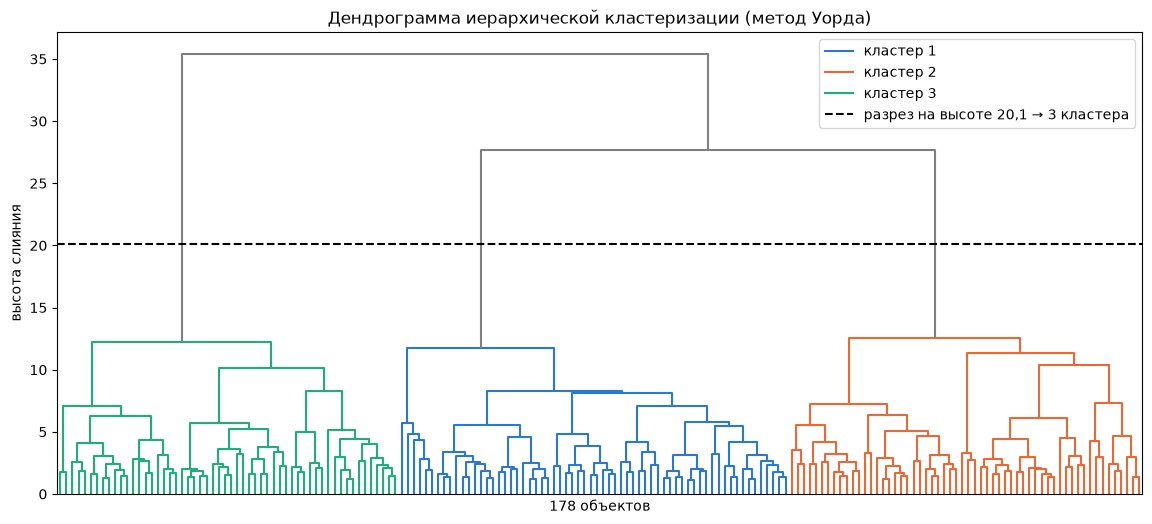

In [22]:
labels_cut = relabel_by_pc1(fcluster(Z, t=cut, criterion='distance'))
node_cluster = list(labels_cut)
for a, b in Z[:, :2].astype(int):
    node_cluster.append(node_cluster[a] if node_cluster[a] == node_cluster[b] else 0)
fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(Z, no_labels=True, ax=ax,
           link_color_func=lambda node: COLORS[node_cluster[node] - 1] if node_cluster[node] else 'gray')
for c in range(1, k_dendro + 1):
    ax.plot([], [], color=COLORS[c - 1], label=f'кластер {c}')
ax.axhline(cut, color='black', ls='--', label=f'разрез на высоте {cut:.1f} → {k_dendro} кластера'.replace('.', ','))
ax.set_ylabel('высота слияния')
ax.set_xlabel('178 объектов')
ax.set_title('Дендрограмма иерархической кластеризации (метод Уорда)')
ax.legend()
fig.savefig('Рисунки/дендрограмма.png', dpi=200, bbox_inches='tight')
plt.show()

Линия разреза на высоте 20,1 пересекает ровно три ветви дерева — это три кластера (цвета ветвей совпадают с цветами
кластеров на остальных рисунках). Внутри каждой ветви все слияния происходят ниже высоты 13, а ветви объединяются
только на высотах 27,7 и 35,4: различие между группами намного больше различий внутри них. Первыми из трёх
объединяются кластеры 1 и 2, кластер 3 присоединяется последним — по критерию Уорда он отличается от двух других
сильнее всего.

Силуэт для разрезов дендрограммы на k = 2…10 кластеров (класс `AgglomerativeClustering` с `linkage='ward'`
строит ту же иерархию, что и `scipy`).

k,2,3,4,5,6,7,8,9,10
силуэт,0.267,0.2774,0.2258,0.1867,0.1797,0.1869,0.1883,0.1917,0.1986


k с наибольшим силуэтом: 3
Совпадение с разрезом дендрограммы scipy (ARI): 1.0
Размеры кластеров: {1: 64, 2: 58, 3: 56}


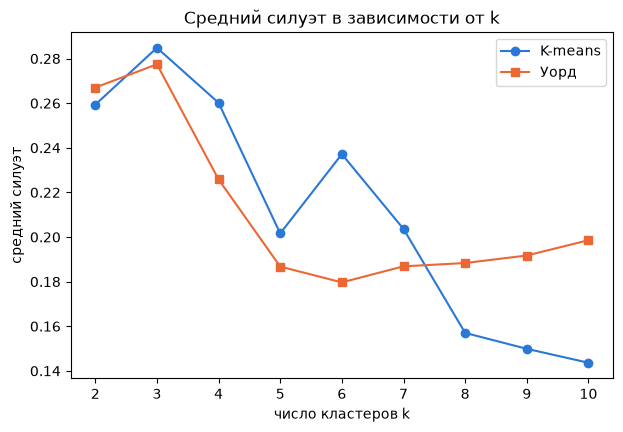

In [23]:
ward_k = range(2, 11)
ward_values = []
for k in ward_k:
    labels = AgglomerativeClustering(n_clusters=k, linkage='ward').fit_predict(X_scaled)
    ward_values.append(silhouette_score(X_scaled, labels))
ward_sil = pd.DataFrame({'силуэт': ward_values}, index=pd.Index(ward_k, name='k'))
display(ward_sil.T.round(4))
ward_sil.to_csv('Результаты/уорд_силуэт.csv', encoding='utf-8')
k_ward = int(ward_sil['силуэт'].idxmax())
labels_ward = relabel_by_pc1(AgglomerativeClustering(n_clusters=k_ward, linkage='ward').fit_predict(X_scaled))
print('k с наибольшим силуэтом:', k_ward)
print('Совпадение с разрезом дендрограммы scipy (ARI):', adjusted_rand_score(fcluster(Z, k_ward, 'maxclust'), labels_ward))
print('Размеры кластеров:', pd.Series(labels_ward).value_counts().sort_index().to_dict())
summary['k_ward'] = k_ward

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(k_table.index[1:], k_table['силуэт'].iloc[1:], 'o-', color=COLORS[0], label='K-means')
ax.plot(ward_sil.index, ward_sil['силуэт'], 's-', color=COLORS[1], label='Уорд')
ax.set_xlabel('число кластеров k')
ax.set_ylabel('средний силуэт')
ax.set_title('Средний силуэт в зависимости от k')
ax.legend()
fig.savefig('Рисунки/силуэт_по_k_оба_метода.png', dpi=200, bbox_inches='tight')
plt.show()

Силуэт метода Уорда тоже максимален при k = 3 (0,277; при k = 2 — 0,267, при k = 4 — 0,226), то есть совпадает с
разрезом по наибольшему скачку высоты. Разрез дендрограммы `scipy` и `AgglomerativeClustering` дают одно и то же
разбиение (ARI = 1,0). Размеры кластеров метода Уорда — 64, 58 и 56. На общем графике кривые обоих методов имеют
максимум при k = 3; у K-means он выше (0,285 против 0,277).

Почему выбрана связь Уорда: для сравнения та же иерархическая процедура с другими способами определить расстояние
между кластерами — по ближайшим объектам (`single`), по самым дальним (`complete`), по среднему расстоянию
(`average`); число кластеров то же.

In [24]:
rows = []
for method in ['ward', 'complete', 'average', 'single']:
    labels = AgglomerativeClustering(n_clusters=k_best, linkage=method).fit_predict(X_scaled)
    rows.append({'связь': method, 'размеры кластеров': sorted(np.bincount(labels).tolist(), reverse=True),
                 'силуэт': silhouette_score(X_scaled, labels), 'ARI с сортами (справочно)': adjusted_rand_score(y_true, labels)})
linkages = pd.DataFrame(rows).set_index('связь')
display(linkages.round(4))
linkages.to_csv('Результаты/способы_связи.csv', encoding='utf-8')

,размеры кластеров,силуэт,ARI с сортами (справочно)
связь,,,
ward,"[64, 58, 56]",0.2774,0.7899
complete,"[69, 58, 51]",0.2038,0.5771
average,"[174, 3, 1]",0.1575,-0.0054
single,"[174, 3, 1]",0.1827,-0.0068


При k = 3 связь Уорда даёт наибольший силуэт (0,277) и три соразмерных кластера (64, 58, 56). Полная связь — силуэт
0,204 и кластеры 69, 58, 51. Средняя и одиночная связи отделяют лишь несколько крайних объектов (кластеры из 3 и
1 объекта), а остальные 174 объекта объединяют в один кластер; для одиночной связи это известный эффект цепочки:
группы, соединённые цепочкой близких объектов, сливаются. Справочно ARI с сортами: 0,790 (Уорд), 0,577 (полная
связь), около 0 (средняя и одиночная). Лучший результат даёт связь Уорда, она и используется.

### 3.4. Проверка осмысленности кластеризации и влияния выбросов
Если структуры нет, кластеризация всё равно выдаст k групп. Проверка: значения каждого признака независимо
перемешиваются между объектами (распределение каждого признака сохраняется, а связи между признаками и группы
разрушаются), и средний силуэт K-means на таких данных сравнивается с силуэтом на настоящих данных.

In [25]:
rng = np.random.default_rng(RANDOM_STATE)
sil_perm = []
for i in range(20):
    X_perm = np.column_stack([rng.permutation(column) for column in X_scaled.T])
    labels_perm = KMeans(n_clusters=k_best, n_init=10, random_state=RANDOM_STATE).fit_predict(X_perm)
    sil_perm.append(silhouette_score(X_perm, labels_perm))
print('Силуэт на перемешанных данных: среднее', round(np.mean(sil_perm), 4), ', максимум', round(np.max(sil_perm), 4))
print('Силуэт на настоящих данных:', round(silhouette_score(X_scaled, labels_km), 4))
summary['силуэт_перемешанные'] = round(float(np.mean(sil_perm)), 6)
summary['силуэт_перемешанные_макс'] = round(float(np.max(sil_perm)), 6)

Силуэт на перемешанных данных: среднее 0.0666 , максимум 0.0732
Силуэт на настоящих данных: 0.2849


На перемешанных данных средний силуэт K-means 0,067 (максимум по 20 перемешиваниям — 0,073), на настоящих —
0,285, более чем в 4 раза выше. Разбиение настоящих данных намного лучше разбиения данных, в которых групп заведомо
нет: структура содержится в совместных значениях признаков, и кластеризация осмысленна.

Влияние выбросов: объекты с выбросами (по каждому из двух правил п. 1.5) удаляются, данные заново
стандартизуются и кластеризуются; разбиение оставшихся объектов сравнивается с исходным по ARI
(1 — разбиения совпадают).

In [26]:
rows = []
for rule, mask_out in [('|z| > 3', out_z.any(axis=1)), ('IQR', out_iqr.any(axis=1))]:
    keep = ~mask_out.to_numpy()
    X_keep = StandardScaler().fit_transform(X[keep])
    km_keep = KMeans(n_clusters=k_best, n_init=10, random_state=RANDOM_STATE).fit_predict(X_keep)
    ward_keep = AgglomerativeClustering(n_clusters=k_ward, linkage='ward').fit_predict(X_keep)
    rows.append({'правило': rule, 'удалено объектов': int(mask_out.sum()),
                 'ARI K-means': adjusted_rand_score(labels_km[keep], km_keep),
                 'ARI Уорд': adjusted_rand_score(labels_ward[keep], ward_keep)})
outlier_effect = pd.DataFrame(rows).set_index('правило')
display(outlier_effect.round(4))
outlier_effect.to_csv('Результаты/влияние_выбросов.csv', encoding='utf-8')
print('Средний силуэт объектов с |z| > 3:', round(sil_values[out_z.any(axis=1)].mean(), 3),
      '; остальных:', round(sil_values[~out_z.any(axis=1)].mean(), 3))
summary['силуэт_выбросов'] = round(float(sil_values[out_z.any(axis=1)].mean()), 6)
summary['силуэт_остальных'] = round(float(sil_values[~out_z.any(axis=1)].mean()), 6)

,удалено объектов,ARI K-means,ARI Уорд
правило,,,
|z| > 3,10,0.9812,0.9311
IQR,17,1.0000,0.9636


Средний силуэт объектов с |z| > 3: 0.112 ; остальных: 0.295


После удаления 10 объектов с |z| > 3 и повторной стандартизации разбиение оставшихся 168 объектов методом K-means
практически совпадает с исходным (ARI = 0,981), методом Уорда — ARI = 0,931; после удаления 17 объектов с выбросами
по IQR — ARI = 1,000 и 0,964. Выбросы почти не влияют на результат, поэтому удалять их не нужно. Объекты с |z| > 3
хуже вписываются в свои кластеры (средний силуэт 0,112 против 0,295 у остальных) — они ближе к границам кластеров.

## 4. Метрики качества кластеризации

### 4.1. Размеры, компактность, центры и расстояния между кластерами
Все расстояния — евклидовы, в стандартизованном пространстве (в нём работали оба метода). Центр кластера —
среднее его объектов. Компактность описывают среднее и максимальное расстояние объектов до центра, среднее
попарное расстояние внутри кластера и WCSS кластера.

In [27]:
def cluster_profile(labels):
    rows = []
    for c in np.unique(labels):
        points = X_scaled[labels == c]
        dist = np.linalg.norm(points - points.mean(axis=0), axis=1)
        rows.append({'кластер': c, 'размер': len(points), 'ср. расстояние до центра': dist.mean(),
                     'макс. расстояние до центра': dist.max(), 'ср. попарное расстояние': pdist(points).mean(),
                     'WCSS кластера': (dist ** 2).sum()})
    return pd.DataFrame(rows).set_index('кластер')

def center_distances(labels):
    centers = pd.DataFrame(X_scaled).groupby(labels).mean()
    return pd.DataFrame(cdist(centers, centers), index=centers.index, columns=centers.index)

for name, labels in [('K-means', labels_km), ('Уорд', labels_ward)]:
    profile, dist_c = cluster_profile(labels), center_distances(labels)
    print(name)
    display(profile.round(2))
    display(dist_c.round(2))
    profile.to_csv('Результаты/профиль_кластеров_' + name + '.csv', encoding='utf-8')
    dist_c.to_csv('Результаты/расстояния_центров_' + name + '.csv', encoding='utf-8')

K-means


,размер,ср. расстояние до центра,макс. расстояние до центра,ср. попарное расстояние,WCSS кластера
кластер,,,,,
1,62,2.34,6.16,3.36,387.88
2,65,2.79,5.40,4.01,561.85
3,51,2.44,4.96,3.49,328.20


,1,2,3
1,0.00,3.60,5.03
2,3.60,0.00,3.97
3,5.03,3.97,0.00


Уорд


,размер,ср. расстояние до центра,макс. расстояние до центра,ср. попарное расстояние,WCSS кластера
кластер,,,,,
1,64,2.35,6.15,3.39,402.20
2,58,2.75,5.87,3.96,494.78
3,56,2.59,5.08,3.70,408.06


,1,2,3
1,0.00,3.54,4.85
2,3.54,0.00,3.87
3,4.85,3.87,0.00


Кластеры K-means: 62, 65 и 51 объект. Самый компактный — кластер 1 (среднее расстояние до центра 2,34), за ним
кластер 3 (2,44); кластер 2 наиболее рыхлый (2,79, среднее попарное расстояние 4,01) — у него и наименьший силуэт.
Наибольшее расстояние до центра — у кластера 1 (6,16): в нём есть отдельные удалённые объекты. Расстояния между
центрами: 1–2 — 3,60, 2–3 — 3,97, 1–3 — 5,03; кластер 2 лежит между двумя другими, как нижняя часть дуги на
проекции PCA. Центры кластеров 1 и 2 удалены на 3,60, а сумма их средних расстояний до центров 2,34 + 2,79 = 5,13
больше: кластеры не разделены широкими промежутками, что согласуется с умеренным силуэтом. У метода Уорда размеры
64, 58 и 56, средние расстояния до центров 2,35, 2,75 и 2,59, а центры немного ближе друг к другу (3,54, 3,87 и
4,85).

### 4.2. Внутренние метрики
Внутренние метрики используют только данные и разбиение:
- средний силуэт (от −1 до 1, больше — лучше);
- индекс Калински–Харабаза $CH = \dfrac{B/(k-1)}{W/(n-k)}$, где $B$ — межгрупповая, $W$ — внутригрупповая сумма
  квадратов (больше — лучше);
- индекс Дэвиса–Боулдина $DB = \frac{1}{k}\sum_i \max_{j \ne i} \dfrac{s_i + s_j}{d_{ij}}$, где $s_i$ — среднее
  расстояние объектов кластера $i$ до его центра, $d_{ij}$ — расстояние между центрами (меньше — лучше);
- WCSS — внутрикластерная сумма квадратов (меньше — компактнее, сравнима только при одинаковом k).

In [28]:
def internal_metrics(labels, data=X_scaled):
    centers = pd.DataFrame(data).groupby(labels).transform('mean').to_numpy()
    return {'силуэт': silhouette_score(data, labels), 'Калински–Харабаз': calinski_harabasz_score(data, labels),
            'Дэвис–Боулдин': davies_bouldin_score(data, labels), 'WCSS': ((data - centers) ** 2).sum()}

internal = pd.DataFrame({'K-means': internal_metrics(labels_km), 'Уорд': internal_metrics(labels_ward)}).T
display(internal.round(3))

,силуэт,Калински–Харабаз,Дэвис–Боулдин,WCSS
K-means,0.285,70.940,1.389,1277.928
Уорд,0.277,67.647,1.419,1305.049


По всем четырём внутренним метрикам K-means немного лучше метода Уорда: силуэт 0,285 против 0,277, индекс
Калински–Харабаза 70,9 против 67,6, индекс Дэвиса–Боулдина 1,389 против 1,419 (меньше — лучше), WCSS 1277,9 против
1305,0. Разница ожидаема: K-means прямо минимизирует WCSS при заданном k, а метод Уорда минимизирует её прирост
пошагово и сделанные слияния не пересматривает. Значения умеренные: DB ≈ 1,4 означает, что для каждого кластера и
самого похожего на него соседа сумма средних расстояний до центров в среднем в 1,4 раза больше расстояния между
центрами.

### 4.3. Внешние метрики
Внешние метрики сравнивают разбиение с известным делением на сорта. Парные индексы считаются по всем
$n(n-1)/2$ парам объектов: TP — пара в одном кластере и одного сорта, FP — в одном кластере, но разных сортов,
FN — разных кластеров, но одного сорта, TN — разных кластеров и разных сортов. Индекс Rand $= (TP + TN)/(TP + FP + FN + TN)$,
индекс Жаккара $= TP/(TP + FP + FN)$ (пары TN, которых большинство, не учитываются). ARI — индекс Rand,
скорректированный на случайное совпадение (0 — как у случайного разбиения, 1 — полное совпадение). NMI —
нормированная взаимная информация; однородность — каждый кластер содержит один сорт, полнота — каждый сорт
попал в один кластер, V-мера — их среднее гармоническое.

В scikit-learn нет функции для парного индекса Жаккара (`jaccard_score` — метрика классификации), поэтому он
считается через `pair_confusion_matrix`. Проверка формулы на маленьком примере ручным перебором пар:

In [29]:
a = [1, 1, 1, 2, 2, 2]
b = [1, 1, 2, 2, 3, 3]
tp = fp = fn = tn = 0
for i, j in combinations(range(len(a)), 2):
    same_a, same_b = a[i] == a[j], b[i] == b[j]
    tp += same_a and same_b
    fn += same_a and not same_b
    fp += same_b and not same_a
    tn += not same_a and not same_b
print('Вручную: TP =', tp, 'FP =', fp, 'FN =', fn, 'TN =', tn,
      '; Rand =', round((tp + tn) / (tp + fp + fn + tn), 4), '; Жаккар =', round(tp / (tp + fp + fn), 4))
C = pair_confusion_matrix(a, b)
print('pair_confusion_matrix:\n', C)
print('По матрице: Rand =', round(rand_score(a, b), 4), '; Жаккар =', round(C[1, 1] / (C[1, 1] + C[0, 1] + C[1, 0]), 4))

Вручную: TP = 2 FP = 1 FN = 4 TN = 8 ; Rand = 0.6667 ; Жаккар = 0.2857
pair_confusion_matrix:
 [[16  2]
 [ 8  4]]
По матрице: Rand = 0.6667 ; Жаккар = 0.2857


Перебор всех 15 пар даёт TP = 2, FP = 1, FN = 4, TN = 8, откуда Rand = 10/15 = 0,667 и Жаккар = 2/7 = 0,286.
`pair_confusion_matrix` считает упорядоченные пары (каждую пару дважды), поэтому её элементы вдвое больше:
[[16, 2], [8, 4]], то есть TN = 16/2 = 8, FP = 2/2 = 1, FN = 8/2 = 4, TP = 4/2 = 2. В отношении множитель 2
сокращается, и TP/(TP + FP + FN) = C[1,1]/(C[1,1] + C[0,1] + C[1,0]) даёт тот же индекс Жаккара 0,286. Формула
проверена; именно она используется в функции `external_metrics`.

In [30]:
def external_metrics(labels):
    C = pair_confusion_matrix(y_true, labels)
    tn, fp, fn, tp = C[0, 0], C[0, 1], C[1, 0], C[1, 1]
    homogeneity, completeness, v_measure = homogeneity_completeness_v_measure(y_true, labels)
    return {'Rand': rand_score(y_true, labels), 'ARI': adjusted_rand_score(y_true, labels),
            'Жаккар': tp / (tp + fp + fn), 'Фоулкс–Мэллоуз': fowlkes_mallows_score(y_true, labels),
            'NMI': normalized_mutual_info_score(y_true, labels), 'однородность': homogeneity,
            'полнота': completeness, 'V-мера': v_measure}

external = pd.DataFrame({'K-means': external_metrics(labels_km), 'Уорд': external_metrics(labels_ward)}).T
display(external.round(3))
for name, labels in [('K-means', labels_km), ('Уорд', labels_ward)]:
    table = pd.crosstab(pd.Series(labels, name='кластер'), y_true.rename('сорт'))
    print(name)
    display(table)
    table.to_csv('Результаты/сопряжённость_' + name + '.csv', encoding='utf-8')

,Rand,ARI,Жаккар,Фоулкс–Мэллоуз,NMI,однородность,полнота,V-мера
K-means,0.954,0.897,0.872,0.932,0.876,0.879,0.873,0.876
Уорд,0.906,0.790,0.755,0.860,0.786,0.790,0.783,0.786


K-means


сорт,1,2,3
кластер,,,
1,59,3,0
2,0,65,0
3,0,3,48


Уорд


сорт,1,2,3
кластер,,,
1,59,5,0
2,0,58,0
3,0,8,48


K-means: Rand 0,954, ARI 0,897, Жаккар 0,872, Фоулкс–Мэллоуз 0,932, NMI 0,876; метод Уорда: 0,906, 0,790, 0,755,
0,860 и 0,786. По таблицам сопряжённости каждый кластер K-means соответствует одному сорту: кластер 1 — 59 образцов
сорта 1 и 3 сорта 2, кластер 2 — 65 образцов сорта 2, кластер 3 — 48 образцов сорта 3 и 3 сорта 2. Все образцы
сортов 1 и 3 попали в «свои» кластеры, а из 71 образца сорта 2 в кластер 2 попали 65 и по 3 — в кластеры 1 и 3:
6 расхождений из 178. У метода Уорда расхождений 13 (5 образцов сорта 2 в кластере 1 и 8 в кластере 3), поэтому у
него ниже и однородность (0,790 против 0,879), и полнота (0,783 против 0,873). Rand высок у обоих методов (0,954 и
0,906), потому что учитывает и пары TN, которых большинство; ARI и индекс Жаккара сильнее реагируют на ошибки.

### 4.4. Сравнительная таблица методов

In [31]:
comparison = pd.concat([internal, external], axis=1)
display(comparison.T.round(3))
comparison.to_csv('Результаты/сравнение_kmeans_уорд.csv', encoding='utf-8')
for name in comparison.index:
    for metric in ['силуэт', 'Калински–Харабаз', 'Дэвис–Боулдин', 'WCSS', 'Rand', 'ARI', 'Жаккар', 'NMI']:
        summary[name + '_' + metric] = round(float(comparison.loc[name, metric]), 6)

,K-means,Уорд
силуэт,0.285,0.277
Калински–Харабаз,70.940,67.647
Дэвис–Боулдин,1.389,1.419
WCSS,1277.928,1305.049
Rand,0.954,0.906
ARI,0.897,0.790
Жаккар,0.872,0.755
Фоулкс–Мэллоуз,0.932,0.860
NMI,0.876,0.786
однородность,0.879,0.790


K-means лучше метода Уорда по всем метрикам. По внутренним разница небольшая (силуэт 0,285 и 0,277), по внешним —
заметная (ARI 0,897 и 0,790, Жаккар 0,872 и 0,755, NMI 0,876 и 0,786). Методы расходятся на 9 пограничных объектах
(п. 6.3); расхождений с сортами у K-means 6, у метода Уорда 13, то есть на спорных объектах K-means чаще совпадает с
сортом. Оба разбиения близки к делению на сорта: ARI намного больше нуля, который соответствует случайному
разбиению.

## 5. Влияние параметров на качество кластеризации

### 5.1. Число кластеров k в K-means

,силуэт,Калински–Харабаз,Дэвис–Боулдин,WCSS,ARI (справочно),NMI (справочно),мин. размер кластера
k,,,,,,,
2,0.259,69.523,1.526,1658.759,0.374,0.478,87
3,0.285,70.940,1.389,1277.928,0.897,0.876,51
4,0.260,56.181,1.797,1175.428,0.765,0.812,29
5,0.202,46.952,1.808,1109.513,0.599,0.673,26
6,0.237,41.701,1.554,1046.002,0.639,0.702,5
7,0.204,38.686,1.661,981.595,0.566,0.674,3
8,0.157,35.805,1.741,935.201,0.415,0.591,3
9,0.150,33.807,1.708,889.893,0.385,0.584,4
10,0.144,32.397,1.707,845.895,0.344,0.576,4


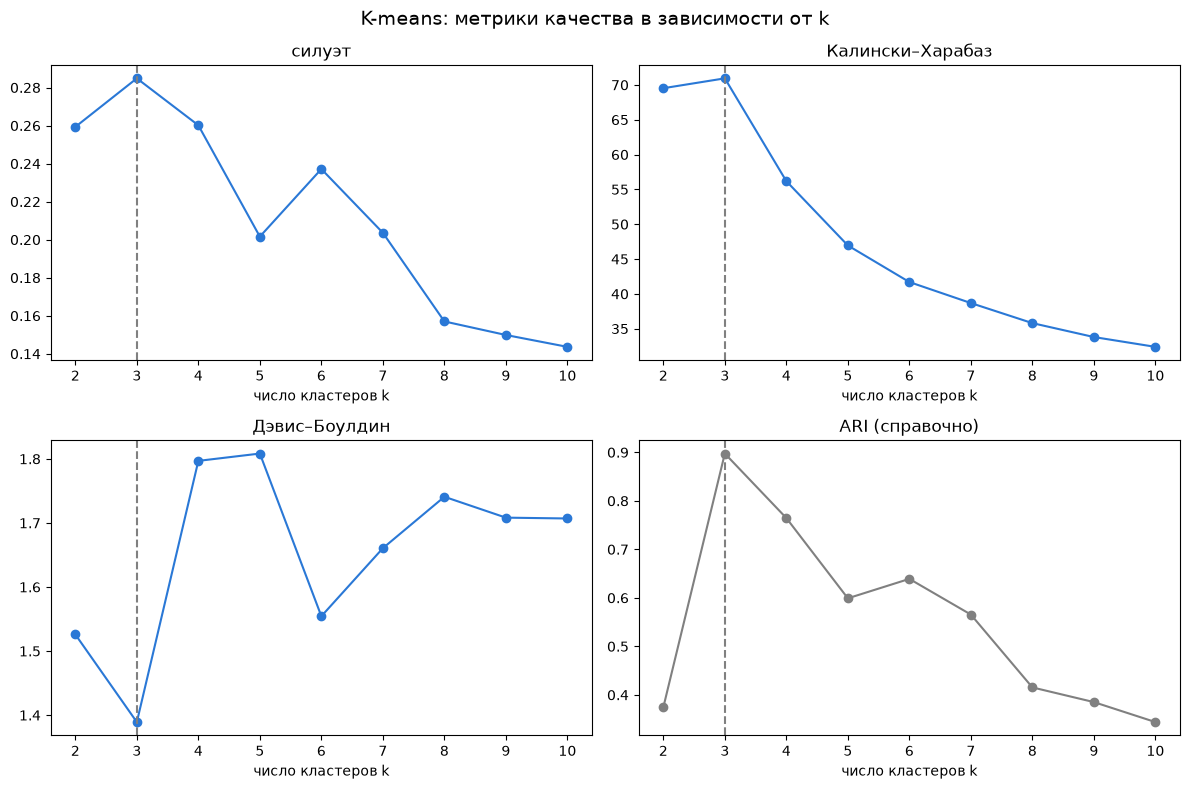

In [32]:
rows = []
for k in range(2, 11):
    labels = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit_predict(X_scaled)
    rows.append({'k': k, **internal_metrics(labels), 'ARI (справочно)': adjusted_rand_score(y_true, labels),
                 'NMI (справочно)': normalized_mutual_info_score(y_true, labels),
                 'мин. размер кластера': np.bincount(labels).min()})
k_effect = pd.DataFrame(rows).set_index('k')
display(k_effect.round(3))
k_effect.to_csv('Результаты/kmeans_влияние_k.csv', encoding='utf-8')

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, metric in zip(axes.flat, ['силуэт', 'Калински–Харабаз', 'Дэвис–Боулдин', 'ARI (справочно)']):
    ax.plot(k_effect.index, k_effect[metric], 'o-', color=COLORS[0] if metric != 'ARI (справочно)' else 'gray')
    ax.axvline(k_best, color='gray', ls='--')
    ax.set_title(metric)
    ax.set_xlabel('число кластеров k')
fig.suptitle('K-means: метрики качества в зависимости от k', fontsize=14)
fig.tight_layout()
fig.savefig('Рисунки/kmeans_метрики_от_k.png', dpi=200, bbox_inches='tight')
plt.show()

При k = 3 у K-means одновременно наибольший силуэт (0,285), наибольший индекс Калински–Харабаза (70,9) и наименьший
индекс Дэвиса–Боулдина (1,389): все три внутренние метрики указывают на одно и то же k. При k = 2 метрики немного
хуже (силуэт 0,259, CH 69,5, DB 1,526), при k ≥ 4 — заметно хуже: CH падает до 56,2 при k = 4 и до 32,4 при k = 10,
DB растёт до 1,80–1,81 при k = 4–5. Местный максимум силуэта при k = 6 (0,237) сопровождается появлением кластера из
5 объектов, при k = 7–8 — из 3 объектов: дробление выделяет очень маленькие группы. Справочные ARI и NMI тоже
максимальны при k = 3 (0,897 и 0,876); при k = 2 ARI = 0,374 (тремя сортам соответствуют только два кластера), при
k = 4 — 0,765. Число кластеров — главный параметр K-means: ошибка в k на единицу заметно ухудшает и внутренние, и
внешние метрики.

### 5.2. DBSCAN: параметры ε и min_samples
DBSCAN относит объект к ядровым, если в его ε-окрестности не меньше `min_samples` объектов (включая сам объект);
кластер — множество ядровых объектов, связанных цепочками соседей, вместе с граничными; остальные объекты — шум
(метка −1). Для выбора ε строится график k-расстояний: для каждого объекта расстояние до `min_samples`-го
ближайшего объекта (включая сам объект, как в DBSCAN), отсортированное по возрастанию. Значение на изгибе
кривой — ориентир для ε. Изгиб найден как точка, наиболее удалённая вниз от прямой, соединяющей концы кривой.

ε на изгибе: 2.71 ; объектов с k-расстоянием не больше ε (ядровых): 144
DBSCAN(ε = 2.71, min_samples = 5): кластеров 1, доля шума 0.101


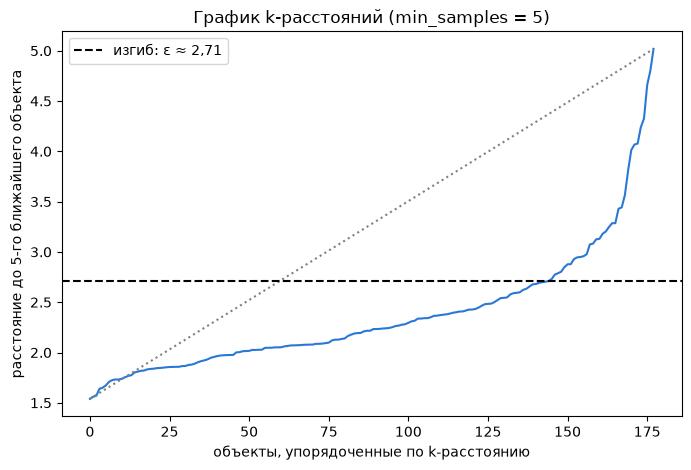

In [33]:
min_samples = 5
nn = NearestNeighbors(n_neighbors=min_samples).fit(X_scaled)
dist, _ = nn.kneighbors(X_scaled)
k_dist = np.sort(dist[:, -1])
idx = np.arange(len(k_dist))
chord = k_dist[0] + (k_dist[-1] - k_dist[0]) * idx / idx[-1]
knee = int(np.argmax(chord - k_dist))
eps_knee = round(float(k_dist[knee]), 2)
labels_knee = DBSCAN(eps=eps_knee, min_samples=min_samples).fit_predict(X_scaled)
print('ε на изгибе:', eps_knee, '; объектов с k-расстоянием не больше ε (ядровых):', int((k_dist <= eps_knee).sum()))
print('DBSCAN(ε = %.2f, min_samples = %d): кластеров %d, доля шума %.3f' % (
    eps_knee, min_samples, len(set(labels_knee) - {-1}), np.mean(labels_knee == -1)))
summary['dbscan_изгиб'] = {'eps': eps_knee, 'ядровых': int((k_dist <= eps_knee).sum()),
                          'кластеров': len(set(labels_knee) - {-1}), 'доля_шума': round(float(np.mean(labels_knee == -1)), 6)}

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(idx, k_dist, color=COLORS[0])
ax.plot([0, idx[-1]], [k_dist[0], k_dist[-1]], color='gray', ls=':')
ax.axhline(eps_knee, color='black', ls='--', label=f'изгиб: ε ≈ {eps_knee}'.replace('.', ','))
ax.set_xlabel('объекты, упорядоченные по k-расстоянию')
ax.set_ylabel(f'расстояние до {min_samples}-го ближайшего объекта')
ax.set_title(f'График k-расстояний (min_samples = {min_samples})')
ax.legend()
fig.savefig('Рисунки/dbscan_k_расстояния.png', dpi=200, bbox_inches='tight')
plt.show()

Кривая k-расстояний полого растёт от 1,5 до 2,7 (у 144 объектов из 178 k-расстояние не больше 2,71), затем резко
поднимается до 5,0 у самых удалённых объектов. Изгиб — ε ≈ 2,71. С ε = 2,71 и min_samples = 5 DBSCAN выделяет один
кластер, а 10,1 % объектов относит к шуму: при ε, при котором большинство объектов становятся ядровыми, три группы
соединяются цепочками ядровых объектов в одну. Стандартный способ выбора ε не находит здесь нескольких кластеров.

Сетка параметров: min_samples ∈ {3, 5, 10, 15, 20}, ε от 1,5 до 3,5 с шагом 0,1. Для каждого варианта —
число кластеров, доля шума, силуэт по объектам, не попавшим в шум (если кластеров не меньше двух), и справочно ARI
с сортами (шум при этом считается отдельной группой).

кластеров,0,1,2,3,4,5,6,7,8,9,10
вариантов,19.0,44.000,26.000,5.00,1.000,2.000,2.000,1.000,2.000,1.000,2.000
мин. доля шума,1.0,0.034,0.017,0.18,0.292,0.360,0.579,0.663,0.506,0.421,0.612
макс. доля шума,1.0,0.910,0.657,0.91,0.292,0.478,0.815,0.663,0.826,0.421,0.697


Наибольший справочный ARI по сетке: 0.43
Варианты с тремя кластерами (по возрастанию доли шума):


,min_samples,eps,кластеров,доля шума,ARI (справочно),силуэт без шума,"шум, %"
8,3,2.3,3,0.180,0.399,0.225,17.978
7,3,2.2,3,0.247,0.387,0.073,24.719
27,5,2.1,3,0.348,0.274,0.222,34.831
71,15,2.3,3,0.545,0.373,0.439,54.494
22,5,1.6,3,0.910,0.028,0.502,91.011


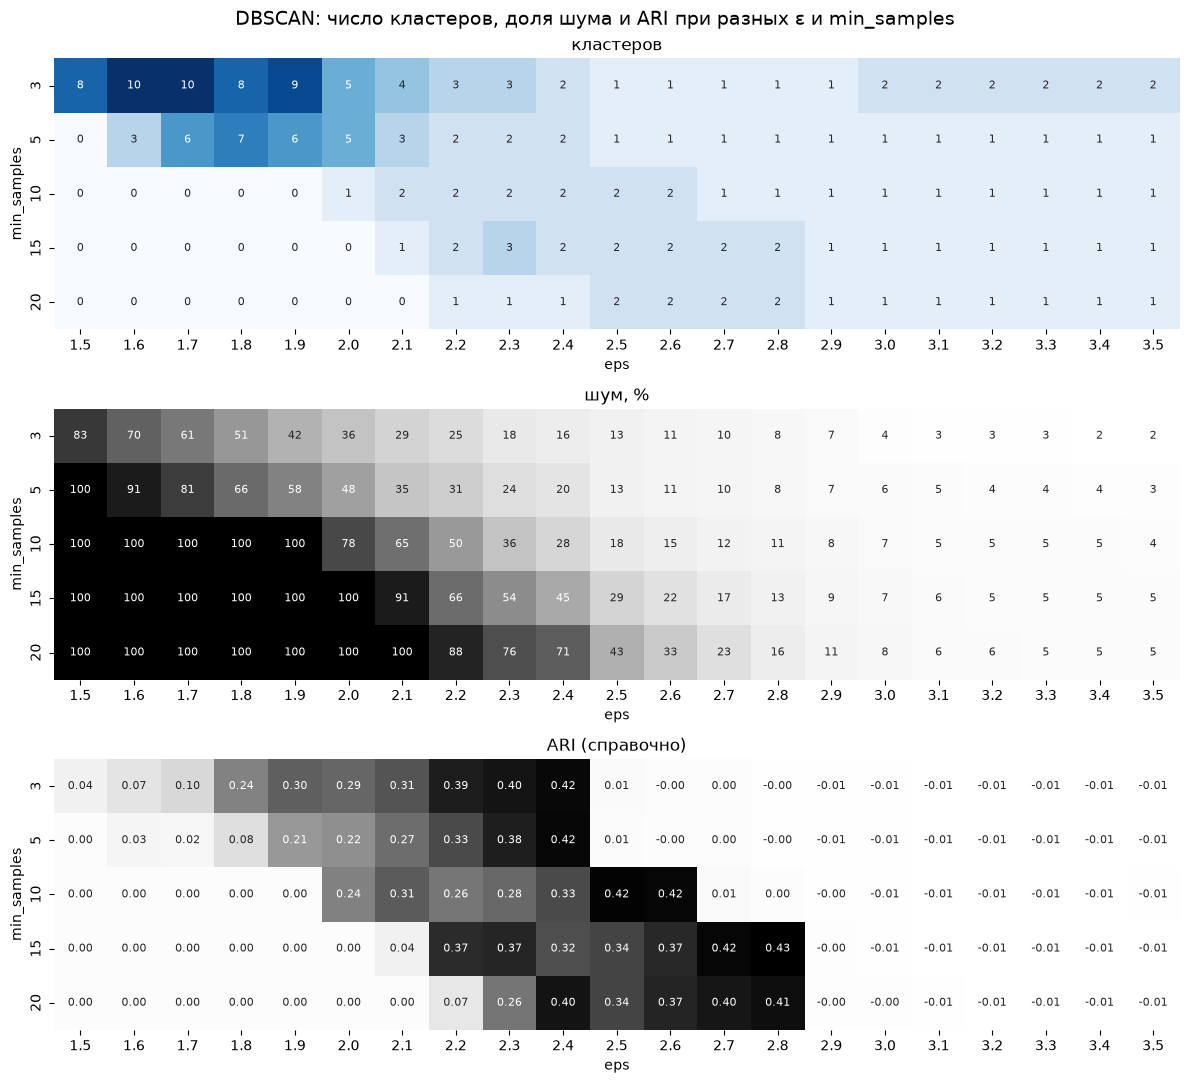

In [34]:
rows = []
for ms in [3, 5, 10, 15, 20]:
    for eps in np.round(np.arange(1.5, 3.51, 0.1), 1):
        labels = DBSCAN(eps=eps, min_samples=ms).fit_predict(X_scaled)
        n_clusters = len(set(labels) - {-1})
        not_noise = labels != -1
        row = {'min_samples': ms, 'eps': eps, 'кластеров': n_clusters, 'доля шума': np.mean(~not_noise),
               'ARI (справочно)': adjusted_rand_score(y_true, labels)}
        if n_clusters >= 2:
            row['силуэт без шума'] = silhouette_score(X_scaled[not_noise], labels[not_noise])
        rows.append(row)
dbscan_grid = pd.DataFrame(rows)
dbscan_grid['шум, %'] = 100 * dbscan_grid['доля шума']
dbscan_grid.to_csv('Результаты/dbscan_сетка.csv', encoding='utf-8', index=False)
by_count = dbscan_grid.groupby('кластеров')['доля шума'].agg(['count', 'min', 'max'])
display(by_count.rename(columns={'count': 'вариантов', 'min': 'мин. доля шума', 'max': 'макс. доля шума'}).round(3).T)
by_count.to_csv('Результаты/dbscan_по_числу_кластеров.csv', encoding='utf-8')
print('Наибольший справочный ARI по сетке:', round(dbscan_grid['ARI (справочно)'].max(), 3))
three = dbscan_grid[dbscan_grid['кластеров'] == 3].sort_values('доля шума')
print('Варианты с тремя кластерами (по возрастанию доли шума):')
display(three.round(3))

fig, axes = plt.subplots(3, 1, figsize=(12, 11))
for ax, value, fmt, cmap in [(axes[0], 'кластеров', 'd', 'Blues'), (axes[1], 'шум, %', '.0f', 'Greys'),
                             (axes[2], 'ARI (справочно)', '.2f', 'Greys')]:
    table = dbscan_grid.pivot(index='min_samples', columns='eps', values=value)
    sns.heatmap(table, annot=True, fmt=fmt, cmap=cmap, cbar=False, annot_kws={'size': 8}, ax=ax)
    ax.set_title(value)
fig.suptitle('DBSCAN: число кластеров, доля шума и ARI при разных ε и min_samples', fontsize=14)
fig.tight_layout()
fig.savefig('Рисунки/dbscan_сетка.png', dpi=200, bbox_inches='tight')
plt.show()

Из 105 вариантов 19 не дали ни одного кластера (все объекты — шум), 44 дали один кластер, 26 — два и только 5 — три
кластера; остальные 11 вариантов с 4–10 кластерами получены при ε ≤ 2,1, когда шумом объявлено от 29 до 83 %
объектов. Три кластера получаются только при доле шума не меньше 18,0 % (min_samples = 3, ε = 2,3; справочный
ARI 0,399). На тепловых картах видна общая закономерность: с ростом ε доля шума падает, а число кластеров сначала
растёт, затем уменьшается до одного; с ростом min_samples та же картина сдвигается к большим ε. Справочный ARI
нигде не превышает 0,43.

Для итогового сравнения (раздел 7) нужен один вариант DBSCAN, выбранный без метки сорта: среди вариантов хотя бы
с двумя кластерами и долей шума не более 20 % взят вариант с наибольшим силуэтом (без шума). Ограничение на шум
нужно, чтобы не выбрать решение, в котором большая часть объектов вообще не кластеризована.

In [35]:
candidates = dbscan_grid[(dbscan_grid['кластеров'] >= 2) & (dbscan_grid['доля шума'] <= 0.2)]
best_db = candidates.loc[candidates['силуэт без шума'].idxmax()]
display(best_db.to_frame('выбранный вариант').T.round(4))
labels_db = DBSCAN(eps=best_db['eps'], min_samples=int(best_db['min_samples'])).fit_predict(X_scaled)
print('Размеры групп (−1 — шум):', pd.Series(labels_db).value_counts().sort_index().to_dict())
table_db = pd.crosstab(pd.Series(labels_db, name='группа DBSCAN'), y_true.rename('сорт'))
display(table_db)
table_db.to_csv('Результаты/сопряжённость_DBSCAN.csv', encoding='utf-8')
summary['dbscan_выбор'] = {'eps': float(best_db['eps']), 'min_samples': int(best_db['min_samples']),
                           'кластеров': int(best_db['кластеров']), 'доля_шума': round(float(best_db['доля шума']), 6)}

,min_samples,eps,кластеров,доля шума,ARI (справочно),силуэт без шума,"шум, %"
выбранный вариант,15.0,2.7,2.0,0.1685,0.4209,0.3258,16.8539


Размеры групп (−1 — шум): {-1: 30, 0: 103, 1: 45}


сорт,1,2,3
группа DBSCAN,,,
-1,1,24,5
0,58,45,0
1,0,2,43


По правилу выбран вариант ε = 2,7, min_samples = 15: два кластера (103 и 45 объектов) и 30 объектов шума (16,9 %),
силуэт без шума 0,326. Кластер 0 объединяет 58 образцов сорта 1 и 45 сорта 2, кластер 1 — 43 образца сорта 3 и
2 сорта 2; в шум попали 24 образца сорта 2, 5 — сорта 3 и 1 — сорта 1. Справочный ARI = 0,421. DBSCAN отделяет
группу, которая соответствует сорту 3, но не разделяет группы, соответствующие сортам 1 и 2, а большую часть
объектов между группами объявляет шумом. Для данных, где группы не разделены областями низкой плотности, это
ожидаемо: связность по плотности либо соединяет соседние группы, либо отбрасывает объекты между ними.

## 6. Визуализация, интерпретация и сравнение методов

### 6.1. Кластеры в пространстве двух главных компонент
Центры кластеров (средние в стандартизованном пространстве) спроецированы тем же преобразованием PCA. Третья
панель — известные сорта (только для сравнения), четвёртая — объекты, которые два метода отнесли к разным кластерам.

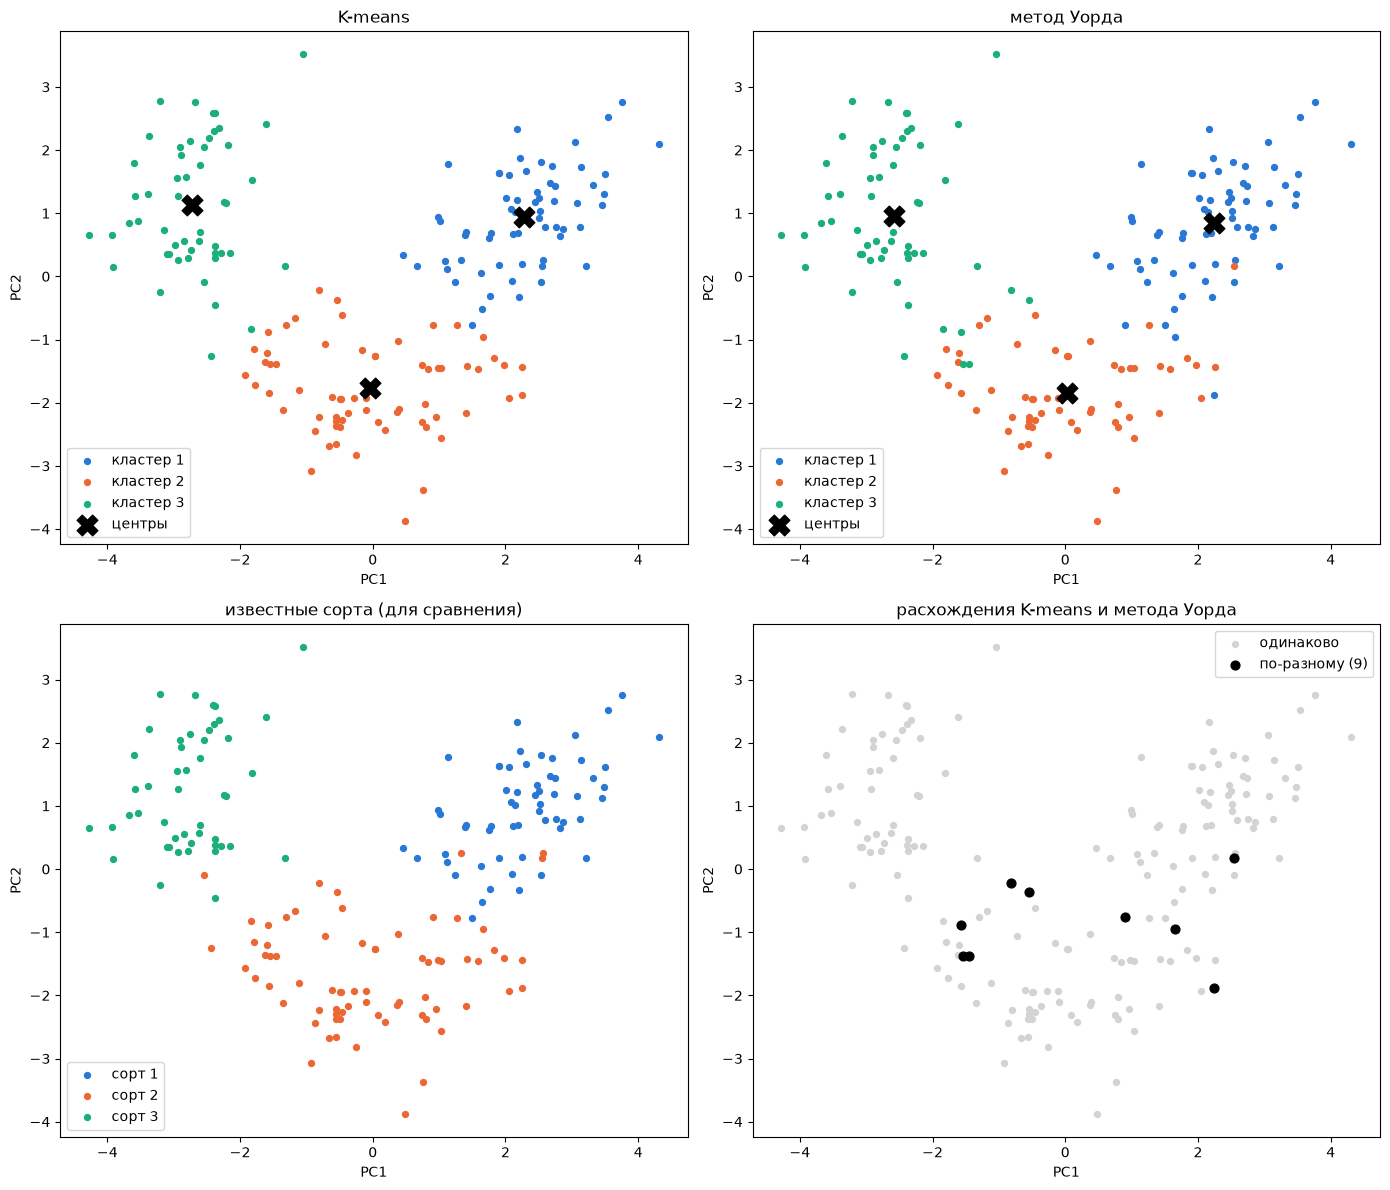

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
panels = [(axes[0, 0], labels_km, 'K-means', 'кластер'), (axes[0, 1], labels_ward, 'метод Уорда', 'кластер'),
          (axes[1, 0], y_true.to_numpy(), 'известные сорта (для сравнения)', 'сорт')]
for ax, labels, title, word in panels:
    for c in np.unique(labels):
        ax.scatter(X_pca[labels == c, 0], X_pca[labels == c, 1], s=18, color=COLORS[c - 1], label=f'{word} {c}')
    if word == 'кластер':
        centers_pca = pca.transform(pd.DataFrame(X_scaled).groupby(labels).mean().to_numpy())
        ax.scatter(centers_pca[:, 0], centers_pca[:, 1], s=220, marker='X', color='black', label='центры')
    ax.set_title(title)
    ax.legend()
diff = labels_km != labels_ward
axes[1, 1].scatter(X_pca[~diff, 0], X_pca[~diff, 1], s=18, color='lightgray', label='одинаково')
axes[1, 1].scatter(X_pca[diff, 0], X_pca[diff, 1], s=40, color='black', label=f'по-разному ({diff.sum()})')
axes[1, 1].set_title('расхождения K-means и метода Уорда')
axes[1, 1].legend()
for ax in axes.flat:
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
fig.tight_layout()
fig.savefig('Рисунки/кластеры_pca.png', dpi=200, bbox_inches='tight')
plt.show()

В проекции на PC1–PC2 кластеры обоих методов совпадают с тремя сгущениями, которые видны на рисунке без меток:
кластер 1 — справа, кластер 2 — внизу, кластер 3 — слева; центры (крестики) лежат внутри сгущений. Известные сорта
(третья панель) расположены так же, а расхождения кластеров с сортами — на стыках нижней группы с двумя другими.
Девять объектов, которые методы отнесли к разным кластерам (четвёртая панель), лежат в переходных зонах между нижним
сгущением и двумя другими. Проекция сохраняет только 55,4 % дисперсии, поэтому точки, которые на плоскости кажутся
«чужими» в кластере, в 13-мерном пространстве могут быть ближе к своему центру.

### 6.2. Центры кластеров в исходных единицах и интерпретация
Центры переведены из стандартизованного пространства в исходные единицы обратным преобразованием
`scaler.inverse_transform` ($x = z \cdot s + \bar{x}$); для сравнения добавлено среднее по всем винам.

In [37]:
centers_scaled = {}
for name, labels in [('K-means', labels_km), ('Уорд', labels_ward)]:
    centers_scaled[name] = pd.DataFrame(X_scaled, columns=X.columns).groupby(labels).mean()
    centers_orig = pd.DataFrame(scaler.inverse_transform(centers_scaled[name]), columns=X.columns,
                                index=[f'кластер {c}' for c in centers_scaled[name].index]).T
    centers_orig['среднее по всем'] = X.mean()
    print(name)
    display(centers_orig.round(3))
    centers_orig.to_csv('Результаты/центры_исходные_' + name + '.csv', encoding='utf-8')

K-means


,кластер 1,кластер 2,кластер 3,среднее по всем
Alcohol,13.677,12.251,13.134,13.001
Malic_acid,1.998,1.897,3.307,2.336
Ash,2.466,2.231,2.418,2.367
Alcalinity_of_ash,17.463,20.063,21.241,19.495
Magnesium,107.968,92.738,98.667,99.742
Total_phenols,2.848,2.248,1.684,2.295
Flavanoids,3.003,2.050,0.819,2.029
Nonflavanoid_phenols,0.292,0.358,0.452,0.362
Proanthocyanins,1.922,1.624,1.146,1.591
Color_intensity,5.454,2.973,7.235,5.058


Уорд


,кластер 1,кластер 2,кластер 3,среднее по всем
Alcohol,13.669,12.204,13.062,13.001
Malic_acid,1.970,1.939,3.167,2.336
Ash,2.463,2.215,2.413,2.367
Alcalinity_of_ash,17.528,20.209,21.004,19.495
Magnesium,106.156,92.552,99.857,99.742
Total_phenols,2.850,2.263,1.694,2.295
Flavanoids,3.010,2.088,0.848,2.029
Nonflavanoid_phenols,0.291,0.355,0.449,0.362
Proanthocyanins,1.908,1.687,1.129,1.591
Color_intensity,5.450,2.895,6.850,5.058


В исходных единицах центры K-means различаются так (в скобках — среднее по всем винам): у кластера 1 наибольшие
Proline 1100 (747), Flavanoids 3,00 (2,03), Total_phenols 2,85 (2,30), Alcohol 13,68 (13,00) и Magnesium 108,0
(99,7); у кластера 2 наименьшие Alcohol 12,25, Color_intensity 2,97 (5,06) и Proline 510; у кластера 3 наибольшие
Color_intensity 7,235, Malic_acid 3,31 (2,34) и Alcalinity_of_ash 21,2 (19,5) и наименьшие Flavanoids 0,82, Hue 0,69
(0,96) и OD280_OD315 1,70 (2,61). Центры метода Уорда близки к центрам K-means: например, Proline кластера 1 —
1076 против 1100, Color_intensity кластера 3 — 6,850 против 7,235.

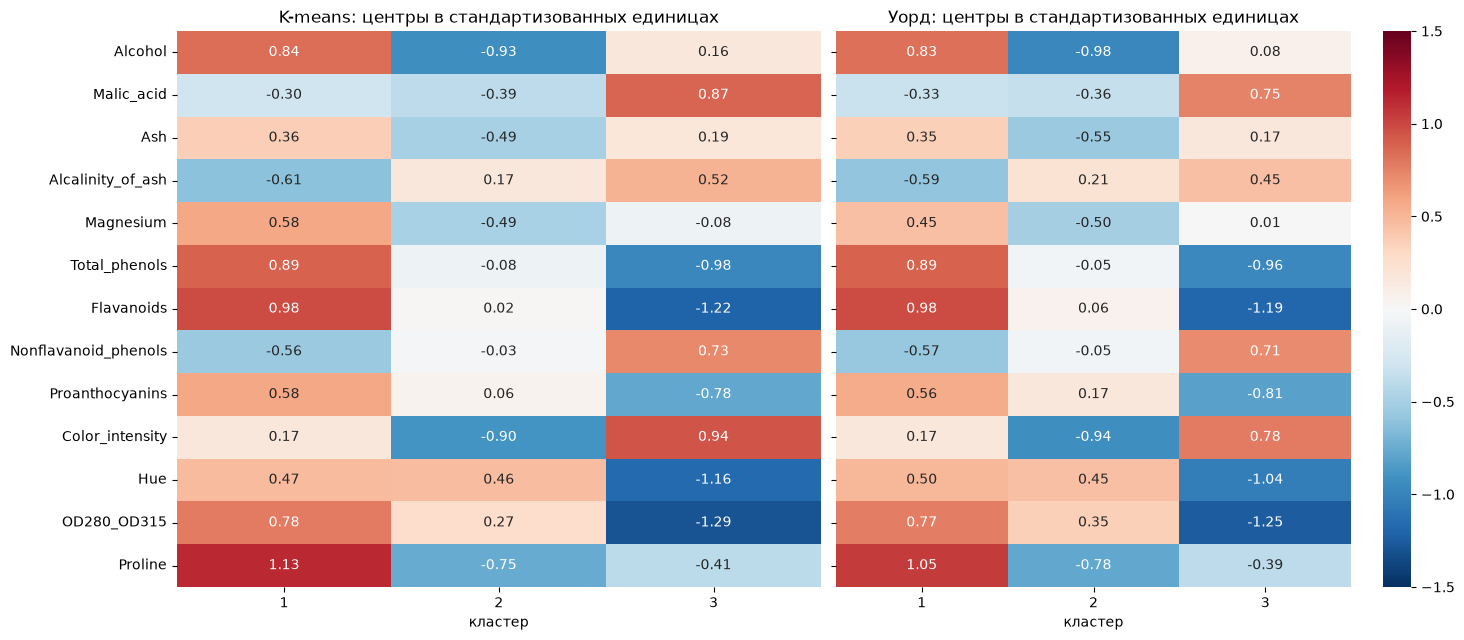

K-means, кластер 1: выше среднего (z > 0,5) — Proline, Flavanoids, Total_phenols, Alcohol, OD280_OD315, Proanthocyanins, Magnesium | ниже среднего (z < −0,5) — Alcalinity_of_ash, Nonflavanoid_phenols
K-means, кластер 2: выше среднего (z > 0,5) —  | ниже среднего (z < −0,5) — Alcohol, Color_intensity, Proline
K-means, кластер 3: выше среднего (z > 0,5) — Color_intensity, Malic_acid, Nonflavanoid_phenols, Alcalinity_of_ash | ниже среднего (z < −0,5) — OD280_OD315, Flavanoids, Hue, Total_phenols, Proanthocyanins
Размах центров K-means по признакам (z): {'Flavanoids': 2.19, 'OD280_OD315': 2.07, 'Proline': 1.88, 'Total_phenols': 1.86, 'Color_intensity': 1.84, 'Alcohol': 1.76, 'Hue': 1.64, 'Proanthocyanins': 1.36, 'Nonflavanoid_phenols': 1.29, 'Malic_acid': 1.27, 'Alcalinity_of_ash': 1.13, 'Magnesium': 1.07, 'Ash': 0.86}
Наибольшее отличие центров Уорда от центров K-means (z): 0.166


In [38]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5), sharey=True)
for ax, name in zip(axes, ['K-means', 'Уорд']):
    sns.heatmap(centers_scaled[name].T, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1.5, vmax=1.5,
                cbar=name == 'Уорд', ax=ax)
    ax.set_title(f'{name}: центры в стандартизованных единицах')
    ax.set_xlabel('кластер')
fig.tight_layout()
fig.savefig('Рисунки/центры_тепловая_карта.png', dpi=200, bbox_inches='tight')
plt.show()
for c, row in centers_scaled['K-means'].iterrows():
    print(f'K-means, кластер {c}: выше среднего (z > 0,5) —', ', '.join(row[row > 0.5].sort_values(ascending=False).index),
          '| ниже среднего (z < −0,5) —', ', '.join(row[row < -0.5].sort_values().index))
centers_scaled['K-means'].to_csv('Результаты/центры_стандартизованные_K-means.csv', encoding='utf-8')
spread = (centers_scaled['K-means'].max() - centers_scaled['K-means'].min()).sort_values(ascending=False)
print('Размах центров K-means по признакам (z):', spread.round(2).to_dict())
print('Наибольшее отличие центров Уорда от центров K-means (z):',
      round((centers_scaled['K-means'] - centers_scaled['Уорд']).abs().max().max(), 3))

Тепловая карта показывает центры в стандартизованных единицах: 0 — среднее по всем винам, ±1 — отклонение на одно
стандартное отклонение. Описание групп только по данным (K-means):
- **кластер 1** (62 образца): выше среднего Proline (z = 1,13), Flavanoids (0,98), Total_phenols (0,89), Alcohol
  (0,84), OD280_OD315 (0,78), Proanthocyanins и Magnesium (0,58); ниже среднего Alcalinity_of_ash (−0,61) и
  Nonflavanoid_phenols (−0,56) — вина с высоким содержанием пролина, фенолов и флавоноидов и с более высоким
  содержанием алкоголя;
- **кластер 2** (65 образцов): ниже среднего Alcohol (−0,93), Color_intensity (−0,90) и Proline (−0,75), а также Ash
  и Magnesium (−0,49); фенольные показатели около среднего (Flavanoids 0,02, Total_phenols −0,08) — вина с
  наименьшими содержанием алкоголя, интенсивностью цвета и содержанием пролина;
- **кластер 3** (51 образец): выше среднего Color_intensity (0,94), Malic_acid (0,87), Nonflavanoid_phenols (0,73) и
  Alcalinity_of_ash (0,52); ниже среднего OD280_OD315 (−1,29), Flavanoids (−1,22), Hue (−1,16), Total_phenols (−0,98)
  и Proanthocyanins (−0,78) — вина с наибольшими интенсивностью цвета и содержанием яблочной кислоты и наименьшими
  содержанием флавоноидов, оттенком (Hue) и OD280/OD315.

Сильнее всего центры различаются по Flavanoids (размах центров 2,19 стандартного отклонения), OD280_OD315 (2,07),
Proline (1,88), Total_phenols (1,86), Color_intensity (1,84) и Alcohol (1,76) — это те же признаки, что лидируют по
доле дисперсии на PC1–PC2 (п. 1.4); слабее всего — по Ash (0,86) и Magnesium (1,07). Центры метода Уорда дают ту же
картину: их отличие от центров K-means не больше 0,17 стандартного отклонения.

### 6.3. Сравнение двух методов между собой

In [39]:
agreement = pd.crosstab(pd.Series(labels_km, name='K-means'), pd.Series(labels_ward, name='Уорд'))
display(agreement)
agreement.to_csv('Результаты/сопряжённость_kmeans_уорд.csv', encoding='utf-8')
print('ARI между разбиениями K-means и Уорда:', round(adjusted_rand_score(labels_km, labels_ward), 4))
print('Объектов в одноимённых кластерах:', int((labels_km == labels_ward).sum()), 'из', len(labels_km))
summary['ARI_kmeans_уорд'] = round(adjusted_rand_score(labels_km, labels_ward), 6)
summary['совпало_kmeans_уорд'] = int((labels_km == labels_ward).sum())

Уорд,1,2,3
K-means,,,
1,61,1,0
2,3,57,5
3,0,0,51


ARI между разбиениями K-means и Уорда: 0.853
Объектов в одноимённых кластерах: 169 из 178


Из 178 объектов 169 методы отнесли к одноимённым кластерам, 9 — к разным; ARI между разбиениями 0,853. Расхождения
сосредоточены на кластере 2 K-means: 3 его объекта метод Уорда отнёс к кластеру 1 и 5 — к кластеру 3; ещё один
объект кластера 1 K-means у Уорда попал в кластер 2. Кластер 3 K-means (51 объект) целиком вошёл в кластер 3 Уорда.
Методы выделяют одни и те же три группы и расходятся только на пограничных объектах.

### 6.4. Устойчивость выделенных групп
Две проверки: (1) K-means из разных начальных состояний `random_state` = 0…19 с одним запуском (`n_init=1`) и с
десятью (`n_init=10`); (2) 100 случайных подвыборок по 80 % объектов без возвращения: каждый метод заново
кластеризует подвыборку, разбиение сравнивается по ARI с разбиением тех же объектов на полных данных.

In [40]:
rows = []
for seed in range(20):
    km1 = KMeans(n_clusters=k_best, n_init=1, random_state=seed).fit(X_scaled)
    km10 = KMeans(n_clusters=k_best, n_init=10, random_state=seed).fit(X_scaled)
    rows.append({'random_state': seed,
                 'инерция, n_init=1': km1.inertia_, 'ARI, n_init=1': adjusted_rand_score(labels_km, km1.labels_),
                 'инерция, n_init=10': km10.inertia_, 'ARI, n_init=10': adjusted_rand_score(labels_km, km10.labels_)})
seeds = pd.DataFrame(rows).set_index('random_state')
display(seeds.describe().loc[['mean', 'min', 'max']].round(4))
print('Разных значений инерции при n_init=1:', seeds['инерция, n_init=1'].round(2).nunique(),
      '; при n_init=10:', seeds['инерция, n_init=10'].round(2).nunique())
seeds.to_csv('Результаты/устойчивость_random_state.csv', encoding='utf-8')

,"инерция, n_init=1","ARI, n_init=1","инерция, n_init=10","ARI, n_init=10"
mean,1279.1661,0.9704,1277.9701,0.9991
min,1277.9285,0.8819,1277.9285,0.9820
max,1282.4635,1.0000,1278.7608,1.0000


Разных значений инерции при n_init=1: 5 ; при n_init=10: 2


При одном запуске (`n_init=1`) результат зависит от начального положения центров: за 20 значений `random_state`
получено 5 разных значений инерции (от 1277,93 до 1282,46), ARI с основным разбиением — от 0,882 до 1. При
`n_init=10` из 10 запусков выбирается решение с наименьшей инерцией: значений инерции только 2 (1277,93 и 1278,76),
ARI не ниже 0,982 (в среднем 0,999). K-means находит локальный минимум инерции, и один запуск может остановиться не в
лучшем — поэтому, как и рекомендует задание, используется несколько инициализаций.

,K-means,Уорд
mean,0.9741,0.8577
std,0.0330,0.0672
min,0.8526,0.6796
25%,0.9573,0.8196
50%,0.9794,0.8729


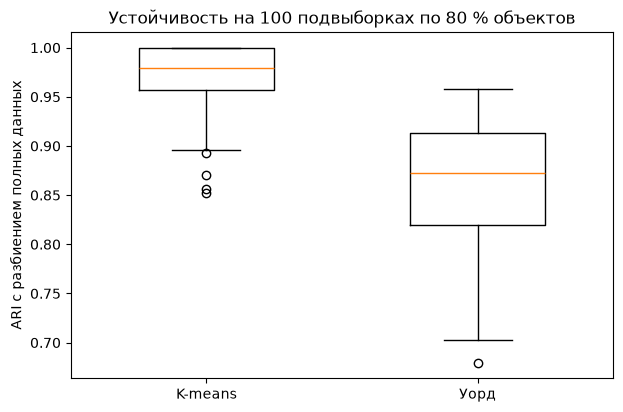

In [41]:
rng = np.random.default_rng(RANDOM_STATE)
ari_km, ari_ward = [], []
for b in range(100):
    sub = rng.choice(len(X_scaled), size=int(0.8 * len(X_scaled)), replace=False)
    km_sub = KMeans(n_clusters=k_best, n_init=10, random_state=RANDOM_STATE).fit_predict(X_scaled[sub])
    ward_sub = AgglomerativeClustering(n_clusters=k_ward, linkage='ward').fit_predict(X_scaled[sub])
    ari_km.append(adjusted_rand_score(labels_km[sub], km_sub))
    ari_ward.append(adjusted_rand_score(labels_ward[sub], ward_sub))
stability = pd.DataFrame({'K-means': ari_km, 'Уорд': ari_ward})
display(stability.describe().loc[['mean', 'std', 'min', '25%', '50%']].round(4))
stability.describe().to_csv('Результаты/устойчивость_подвыборки.csv', encoding='utf-8')
summary['устойчивость_kmeans_ARI_среднее'] = round(float(stability['K-means'].mean()), 6)
summary['устойчивость_уорд_ARI_среднее'] = round(float(stability['Уорд'].mean()), 6)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.boxplot([stability['K-means'], stability['Уорд']], tick_labels=['K-means', 'Уорд'], widths=0.5)
ax.set_ylabel('ARI с разбиением полных данных')
ax.set_title('Устойчивость на 100 подвыборках по 80 % объектов')
fig.savefig('Рисунки/устойчивость.png', dpi=200, bbox_inches='tight')
plt.show()

На 100 подвыборках по 80 % объектов K-means воспроизводит своё разбиение с ARI в среднем 0,974 (медиана 0,979,
минимум 0,853), метод Уорда — в среднем 0,858 (медиана 0,873, минимум 0,680). Группы K-means устойчивы к составу
выборки. Дерево Уорда чувствительнее: это согласуется с тем, что алгоритм жадный — изменение состава данных может
изменить ранние слияния, а они потом не пересматриваются.

## 7. Дополнительное задание: глубокая кластеризация

### 7.1. Метод и архитектура
Выбран вариант «автокодировщик + K-means» с уточнением DEC (Deep Embedded Clustering). Автокодировщик — нейронная
сеть, которая учится восстанавливать свой вход через узкий промежуточный слой: кодировщик сжимает 13 признаков в
`latent_dim` чисел (латентные признаки), декодировщик восстанавливает по ним 13 признаков. Если восстановление
точное, латентные признаки сохраняют основную информацию об объекте в меньшей размерности, и K-means ищет кластеры
уже в этом пространстве.

Архитектура: 13 → 8 (ReLU) → `latent_dim` (линейный слой) → 8 (ReLU) → 13 (линейный слой).
- Сеть небольшая (несколько сотен весов), потому что объектов всего 178: чем больше у сети весов по сравнению с
  объёмом данных, тем выше риск переобучения.
- Скрытые слои с функцией активации ReLU позволяют строить нелинейные латентные признаки — в этом отличие от PCA,
  который даёт только линейные комбинации признаков.
- Латентный и выходной слои линейные: стандартизованные признаки и латентные координаты могут иметь любой знак, а
  ReLU обрезала бы отрицательные значения.
- Функция потерь — среднеквадратичная ошибка восстановления
  $MSE = \frac{1}{13n}\sum_{i=1}^{n}\sum_{j=1}^{13}(x_{ij} - \hat{x}_{ij})^2$: признаки непрерывные и стандартизованные,
  а MSE объекта — это квадрат евклидова расстояния между входом и его восстановлением, то есть та же мера различия,
  что используется в K-means.
- L2-регуляризация добавляет к потерям штраф $\lambda \sum w^2$ и не даёт весам становиться большими, что уменьшает
  переобучение.
- Оптимизатор Adam подбирает шаг обучения для каждого веса отдельно.

In [42]:
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import tensorflow as tf

tf.config.experimental.enable_op_determinism()
X_ae = X_scaled.astype('float32')
X_ae_train, X_ae_val = train_test_split(X_ae, test_size=0.2, random_state=RANDOM_STATE)
print('TensorFlow', tf.__version__, '; обучение:', X_ae_train.shape, '; проверка:', X_ae_val.shape)

def build_autoencoder(latent_dim, learning_rate, l2):
    tf.keras.utils.set_random_seed(RANDOM_STATE)
    reg = tf.keras.regularizers.l2(l2)
    inputs = tf.keras.Input(shape=(X_ae.shape[1],))
    hidden = tf.keras.layers.Dense(8, activation='relu', kernel_regularizer=reg)(inputs)
    latent = tf.keras.layers.Dense(latent_dim, kernel_regularizer=reg, name='latent')(hidden)
    hidden = tf.keras.layers.Dense(8, activation='relu', kernel_regularizer=reg)(latent)
    outputs = tf.keras.layers.Dense(X_ae.shape[1], kernel_regularizer=reg)(hidden)
    autoencoder = tf.keras.Model(inputs, outputs)
    encoder = tf.keras.Model(inputs, latent)
    autoencoder.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate), loss='mse')
    return autoencoder, encoder

autoencoder, encoder = build_autoencoder(latent_dim=3, learning_rate=0.001, l2=0.001)
for layer in autoencoder.layers:
    print(f'{layer.name:12s} выход {str(layer.output.shape):12s} параметров {layer.count_params()}')
print('Всего обучаемых параметров:', autoencoder.count_params())

TensorFlow 2.21.0 ; обучение: (142, 13) ; проверка: (36, 13)
input_layer  выход (None, 13)   параметров 0
dense        выход (None, 8)    параметров 112
latent       выход (None, 3)    параметров 27
dense_1      выход (None, 8)    параметров 32
dense_2      выход (None, 13)   параметров 117
Всего обучаемых параметров: 288


В показанном варианте (`latent_dim` = 3) у сети 288 обучаемых параметров: 112 в первом слое (13 × 8 весов +
8 смещений), 27 в латентном (8 × 3 + 3), 32 и 117 в слоях декодировщика. Для оценки ошибки восстановления на
объектах, которых сеть не видела, данные разбиты на обучающую часть (142 объекта) и проверочную (36 объектов); метка
сорта при этом не используется.

### 7.2. Подбор гиперпараметров
Сетка: размерность латентного пространства `latent_dim` ∈ {2, 3, 5}, скорость обучения `lr` ∈ {0,001; 0,01},
коэффициент L2-регуляризации ∈ {0; 0,001; 0,01} — 18 автокодировщиков; на латентных признаках каждого — K-means с
k = 2…6. Обучение — 300 эпох, пакеты по 16 объектов.

Правило выбора (без метки сорта):
1. `lr` и L2 управляют обучением сети и переобучением, поэтому для каждой размерности они выбираются по ошибке
   восстановления MSE на проверочных объектах.
2. `latent_dim` и k определяют сами кластеры, поэтому они выбираются по силуэту разбиения, посчитанному в исходном
   стандартизованном пространстве. Силуэт в латентном пространстве для этого не годится: при разной размерности и
   разном масштабе латентных признаков (L2 его меняет) он считается в разных пространствах и между вариантами не
   сравним.

ARI с сортами записывается только справочно.

In [43]:
EPOCHS, BATCH_SIZE = 300, 16
rows = []
for latent_dim in [2, 3, 5]:
    for lr in [0.001, 0.01]:
        for l2 in [0.0, 0.001, 0.01]:
            autoencoder, encoder = build_autoencoder(latent_dim, lr, l2)
            autoencoder.fit(X_ae_train, X_ae_train, epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)
            mse_train = mean_squared_error(X_ae_train, autoencoder(X_ae_train).numpy())
            mse_val = mean_squared_error(X_ae_val, autoencoder(X_ae_val).numpy())
            Z_lat = encoder(X_ae).numpy()
            for k in range(2, 7):
                labels = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit_predict(Z_lat)
                rows.append({'latent_dim': latent_dim, 'lr': lr, 'l2': l2, 'k': k, 'MSE обучение': mse_train,
                             'MSE проверка': mse_val, 'силуэт (латентное)': silhouette_score(Z_lat, labels),
                             'силуэт (исходное)': silhouette_score(X_scaled, labels),
                             'ARI (справочно)': adjusted_rand_score(y_true, labels)})
ae_grid = pd.DataFrame(rows)
ae_grid.to_csv('Результаты/автокодировщик_сетка.csv', encoding='utf-8', index=False)
ae_table = ae_grid.groupby(['latent_dim', 'lr', 'l2'])[['MSE обучение', 'MSE проверка']].first()
display(ae_table.round(3))
print('Разброс по 18 конфигурациям при k = 3:')
display(ae_grid[ae_grid['k'] == 3][['силуэт (исходное)', 'ARI (справочно)']].agg(['min', 'max']).round(4))

MSE обучение  MSE проверка
latent_dim lr    l2                               
2          0.001 0.000         0.380         0.325
                 0.001         0.378         0.328
                 0.010         0.409         0.327
           0.010 0.000         0.315         0.350
                 0.001         0.325         0.323
                 0.010         0.406         0.324
3          0.001 0.000         0.348         0.322
                 0.001         0.344         0.313
                 0.010         0.350         0.293
           0.010 0.000         0.250         0.282
                 0.001         0.232         0.267
                 0.010         0.312         0.279
5          0.001 0.000         0.237         0.244
                 0.001         0.234         0.239
                 0.010         0.333         0.279
           0.010 0.000         0.163         0.190
                 0.001         0.154         0.156
                 0.010         0.316         0.270

Разброс по 18 конфигурациям при k = 3:


,силуэт (исходное),ARI (справочно)
min,0.1279,0.3749
max,0.2823,0.8943


Ошибка восстановления на проверке уменьшается с ростом `latent_dim` (лучшие значения 0,323 при 2, 0,267 при 3 и
0,156 при 5): чем больше латентных признаков, тем больше информации проходит через узкий слой. При `lr` = 0,001 сеть
за 300 эпох обучается хуже, чем при 0,01 (для `latent_dim` = 5 без регуляризации MSE на проверке 0,244 против 0,190).
Без регуляризации при `lr` = 0,01 ошибка на обучении ниже, чем на проверке (для `latent_dim` = 2 — 0,315 против
0,350, для 5 — 0,163 против 0,190): признак переобучения. L2 = 0,001 уменьшает ошибку на проверке при всех трёх
размерностях (до 0,323; 0,267 и 0,156). Слишком сильная регуляризация L2 = 0,01 ухудшает и обучение, и проверку
(например, 0,316 и 0,270 при `latent_dim` = 5): штраф за величину весов начинает мешать восстановлению.

По всем 18 конфигурациям при k = 3 силуэт в исходном пространстве меняется от 0,128 до 0,282, справочный ARI — от
0,375 до 0,894: результат глубокой кластеризации сильно зависит от гиперпараметров.

In [44]:
best_per_dim = ae_table['MSE проверка'].groupby(level='latent_dim').idxmin()
print('Лучшие (lr, l2) по ошибке на проверке для каждой размерности:', best_per_dim.to_dict())
chosen = ae_grid.set_index(['latent_dim', 'lr', 'l2']).loc[list(best_per_dim)].reset_index()
pivot = chosen.pivot(index='k', columns='latent_dim', values='силуэт (исходное)')
display(pivot.round(4))
display(chosen.pivot(index='k', columns='latent_dim', values='силуэт (латентное)').round(4))
best_row = chosen.loc[chosen['силуэт (исходное)'].idxmax()]
best_dim, k_dec = int(best_row['latent_dim']), int(best_row['k'])
best_lr, best_l2 = float(best_row['lr']), float(best_row['l2'])
print(f'Выбрано: latent_dim = {best_dim}, lr = {best_lr}, l2 = {best_l2}, k = {k_dec}')
chosen.to_csv('Результаты/автокодировщик_выбор.csv', encoding='utf-8', index=False)
summary['DEC_гиперпараметры'] = {'latent_dim': best_dim, 'lr': best_lr, 'l2': best_l2, 'k': k_dec}

Лучшие (lr, l2) по ошибке на проверке для каждой размерности: {2: (2, 0.01, 0.001), 3: (3, 0.01, 0.001), 5: (5, 0.01, 0.001)}


latent_dim,2,3,5
k,,,
2,0.2502,0.2676,0.2587
3,0.2776,0.2719,0.2792
4,0.2370,0.2100,0.2139
5,0.1900,0.2167,0.2149
6,0.1940,0.1784,0.1883


latent_dim,2,3,5
k,,,
2,0.5010,0.4522,0.4368
3,0.4733,0.4686,0.3397
4,0.4550,0.4372,0.3018
5,0.4222,0.4506,0.3034
6,0.4584,0.3818,0.2817


Выбрано: latent_dim = 5, lr = 0.01, l2 = 0.001, k = 3


Для всех трёх размерностей наименьшая ошибка на проверке получена при `lr` = 0,01 и L2 = 0,001. Среди этих трёх
автокодировщиков силуэт в исходном пространстве наибольший при `latent_dim` = 5 и k = 3 (0,279); при
`latent_dim` = 2 и k = 3 — 0,278, при `latent_dim` = 3 и k = 3 — 0,272, при k = 2 и k ≥ 4 силуэт ниже для всех
размерностей. Разница между размерностями мала (0,272–0,279). Силуэт в латентном пространстве ведёт себя иначе: при
`latent_dim` = 2 и 5 он наибольший при k = 2 (0,501 и 0,437), то есть выбор по нему дал бы два кластера; к тому же
его значения уменьшаются с ростом размерности (для k = 3: 0,473, 0,469 и 0,340). Выбрано: `latent_dim` = 5,
`lr` = 0,01, L2 = 0,001, k = 3.

### 7.3. Обучение выбранного автокодировщика и K-means на латентных признаках

MSE на проверке (как в сетке): 0.1562
Размеры кластеров: {1: 60, 2: 66, 3: 52}


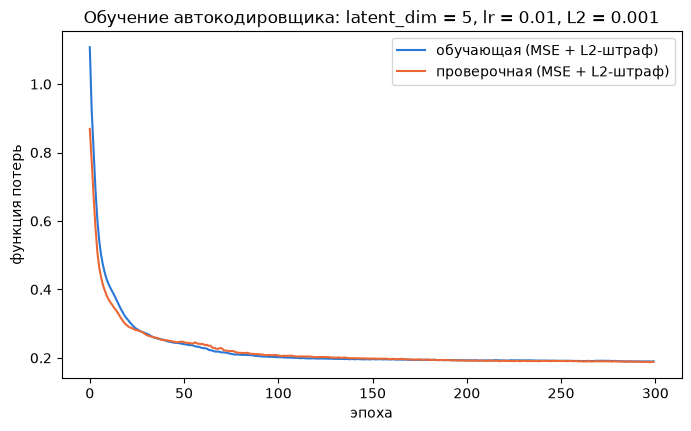

In [45]:
autoencoder, encoder = build_autoencoder(best_dim, best_lr, best_l2)
history = autoencoder.fit(X_ae_train, X_ae_train, validation_data=(X_ae_val, X_ae_val),
                          epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)
print('MSE на проверке (как в сетке):', round(mean_squared_error(X_ae_val, autoencoder(X_ae_val).numpy()), 4))
Z_ae = encoder(X_ae).numpy()
kmeans_ae = KMeans(n_clusters=k_dec, n_init=10, random_state=RANDOM_STATE).fit(Z_ae)
labels_ae = relabel_by_pc1(kmeans_ae.labels_)
print('Размеры кластеров:', pd.Series(labels_ae).value_counts().sort_index().to_dict())

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(history.history['loss'], color=COLORS[0], label='обучающая (MSE + L2-штраф)')
ax.plot(history.history['val_loss'], color=COLORS[1], label='проверочная (MSE + L2-штраф)')
ax.set_xlabel('эпоха')
ax.set_ylabel('функция потерь')
ax.set_title(f'Обучение автокодировщика: latent_dim = {best_dim}, lr = {best_lr}, L2 = {best_l2}')
ax.legend()
fig.savefig('Рисунки/автокодировщик_обучение.png', dpi=200, bbox_inches='tight')
plt.show()

Повторное обучение выбранной конфигурации дало ту же ошибку на проверке 0,1562, что и в сетке, — результат
воспроизводим. Потери быстро падают за первые 25–50 эпох и к 150-й эпохе выходят на плато около 0,19; проверочная
кривая идёт вровень с обучающей, расхождения, характерного для переобучения, нет. На графике потери включают
L2-штраф, поэтому они выше чистой MSE (0,156). K-means на пятимерных латентных признаках дал кластеры из 60, 66 и
52 объектов.

### 7.4. Уточнение кластеров методом DEC
DEC дообучает кодировщик вместе с центрами кластеров так, чтобы назначения объектов кластерам стали увереннее.
1. Мягкое назначение объекта $i$ кластеру $j$ — по t-распределению Стьюдента с одной степенью свободы:
   $q_{ij} = \dfrac{(1 + \lVert z_i - \mu_j \rVert^2)^{-1}}{\sum_{j'} (1 + \lVert z_i - \mu_{j'} \rVert^2)^{-1}}$,
   где $z_i$ — латентные признаки объекта, $\mu_j$ — центр кластера (начальные центры — из K-means на латентных
   признаках).
2. Целевое распределение усиливает уверенные назначения: $p_{ij} = \dfrac{q_{ij}^2 / f_j}{\sum_{j'} q_{ij'}^2 / f_{j'}}$,
   где $f_j = \sum_i q_{ij}$ — «размер» кластера; деление на него не даёт крупным кластерам поглощать остальные.
3. Функция потерь — расхождение Кульбака–Лейблера $KL(P\,\|\,Q) = \sum_i \sum_j p_{ij} \log \dfrac{p_{ij}}{q_{ij}}$.
   Её минимизирует Adam с тем же шагом 0,01, что выбран для автокодировщика, обновляя и веса кодировщика, и центры
   $\mu_j$. Цель P пересчитывается каждые 10 итераций, всего 1000 итераций по всем 178 объектам; метка сорта не
   используется.

In [46]:
class ClusteringLayer(tf.keras.layers.Layer):

    def __init__(self, n_clusters, **kwargs):
        super().__init__(**kwargs)
        self.n_clusters = n_clusters

    def build(self, input_shape):
        self.centers = self.add_weight(name='centers', shape=(self.n_clusters, input_shape[-1]), initializer='zeros')

    def call(self, z):
        dist2 = tf.reduce_sum(tf.square(tf.expand_dims(z, axis=1) - self.centers), axis=2)
        q = 1.0 / (1.0 + dist2)
        return q / tf.reduce_sum(q, axis=1, keepdims=True)

def target_distribution(q):
    weight = q ** 2 / q.sum(axis=0)
    return weight / weight.sum(axis=1, keepdims=True)

clustering = ClusteringLayer(k_dec, name='clustering')
dec = tf.keras.Model(encoder.input, clustering(encoder.output))
clustering.set_weights([kmeans_ae.cluster_centers_])
dec.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=best_lr), loss='kld')

MAX_ITER, UPDATE_INTERVAL = 1000, 10
labels_prev = kmeans_ae.labels_.copy()
dec_log = []
for it in range(MAX_ITER + 1):
    if it % UPDATE_INTERVAL == 0:
        q = dec(X_ae).numpy()
        p = target_distribution(q)
        labels_now = q.argmax(axis=1)
        dec_log.append({'итерация': it, 'KL(P||Q)': float(np.sum(p * np.log(p / q)) / len(p)),
                        'доля сменивших кластер': np.mean(labels_now != labels_prev),
                        'средняя max q': q.max(axis=1).mean()})
        labels_prev = labels_now
    if it < MAX_ITER:
        dec.train_on_batch(X_ae, p)
dec_log = pd.DataFrame(dec_log).set_index('итерация')
display(dec_log.iloc[[0, 1, 2, 5, 10, 20, 50, 100]].round(4))
q = dec(X_ae).numpy()
labels_dec = relabel_by_pc1(q.argmax(axis=1))
Z_dec = encoder(X_ae).numpy()
changes = (dec_log['доля сменивших кластер'] * len(X_ae)).round().astype(int)
print('Смен кластера за всё уточнение:', changes.sum(), '; из них после 150-й итерации:', changes[changes.index > 150].sum())
print('Размеры кластеров DEC:', pd.Series(labels_dec).value_counts().sort_index().to_dict())
print('ARI между AE + K-means и DEC:', round(adjusted_rand_score(labels_ae, labels_dec), 4),
      '; объектов в другом кластере:', int((labels_ae != labels_dec).sum()))
table_ae_dec = pd.crosstab(pd.Series(labels_ae, name='AE + K-means'), pd.Series(labels_dec, name='DEC'))
display(table_ae_dec)
table_ae_dec.to_csv('Результаты/сопряжённость_AE_DEC.csv', encoding='utf-8')
dec_log.to_csv('Результаты/dec_обучение.csv', encoding='utf-8')
summary['DEC_смен_всего'] = int(changes.sum())
summary['DEC_смен_после_150'] = int(changes[changes.index > 150].sum())
summary['ARI_AE_DEC'] = round(adjusted_rand_score(labels_ae, labels_dec), 6)
summary['AE_DEC_различий'] = int((labels_ae != labels_dec).sum())

,KL(P||Q),доля сменивших кластер,средняя max q
итерация,,,
0,0.0983,0.0000,0.6872
10,0.0959,0.0056,0.7766
20,0.0866,0.0112,0.8323
50,0.0722,0.0000,0.8845
100,0.0603,0.0056,0.9053
200,0.0499,0.0000,0.9292
500,0.0421,0.0000,0.9416
1000,0.0355,0.0000,0.9539


Смен кластера за всё уточнение: 11 ; из них после 150-й итерации: 2
Размеры кластеров DEC: {1: 62, 2: 61, 3: 55}
ARI между AE + K-means и DEC: 0.8552 ; объектов в другом кластере: 9


DEC,1,2,3
AE + K-means,,,
1,60,0,0
2,2,59,5
3,0,2,50


Средняя уверенность назначений (наибольшая $q_{ij}$ объекта) выросла с 0,687 до 0,954, KL(P‖Q) уменьшилась с 0,098
до 0,036. Кластер меняют единичные объекты: за всё уточнение было 11 смен, из них только 2 — после 150-й итерации.
Итоговые кластеры DEC — 62, 61 и 55 объектов; с разбиением «автокодировщик + K-means» они совпадают с ARI = 0,855,
в другом кластере оказались 9 объектов (2 перешли из кластера 2 в кластер 1, 5 — из кластера 2 в кластер 3, 2 — из
кластера 3 в кластер 2).

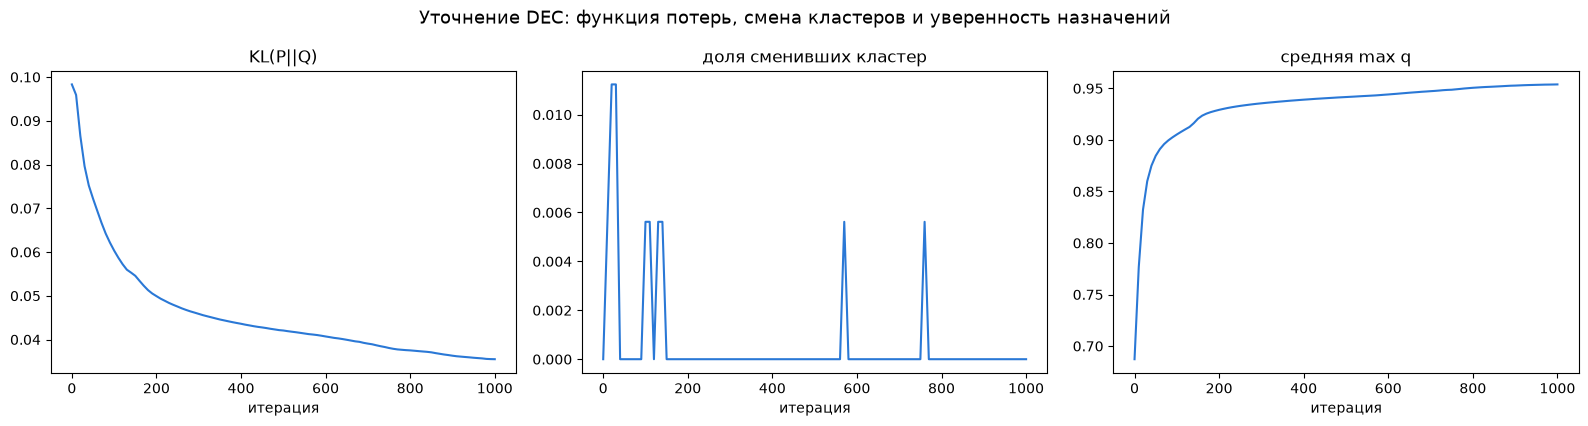

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.3))
for ax, column in zip(axes, dec_log.columns):
    ax.plot(dec_log.index, dec_log[column], color=COLORS[0])
    ax.set_title(column)
    ax.set_xlabel('итерация')
fig.suptitle('Уточнение DEC: функция потерь, смена кластеров и уверенность назначений', fontsize=13)
fig.tight_layout()
fig.savefig('Рисунки/dec_обучение.png', dpi=200, bbox_inches='tight')
plt.show()

KL плавно убывает — оптимизация идёт; доля сменивших кластер почти всё время равна нулю; уверенность назначений
растёт и выходит на плато около 0,95. DEC сделал назначения увереннее, но разбиение изменил мало.

### 7.5. Сравнение с классическими методами
Для сравнения добавлен EM-алгоритм (`GaussianMixture`) с тем же числом компонент; тип ковариационных матриц
выбран по наименьшему байесовскому информационному критерию BIC. Внутренние метрики всех методов считаются в одном
и том же исходном стандартизованном пространстве (в латентном пространстве их нельзя сравнивать между методами);
для DBSCAN — по объектам без шума.

In [48]:
bic = {cov: GaussianMixture(n_components=k_best, covariance_type=cov, n_init=10, random_state=RANDOM_STATE)
            .fit(X_scaled).bic(X_scaled) for cov in ['full', 'tied', 'diag', 'spherical']}
best_cov = min(bic, key=bic.get)
print('BIC по типам ковариации:', {cov: round(v, 1) for cov, v in bic.items()}, '→ выбран', best_cov)
gmm = GaussianMixture(n_components=k_best, covariance_type=best_cov, n_init=10,
                      random_state=RANDOM_STATE).fit(X_scaled)
labels_gmm = relabel_by_pc1(gmm.predict(X_scaled))
summary['GMM_ковариация'] = best_cov
summary['GMM_BIC'] = {cov: round(float(v), 2) for cov, v in bic.items()}

methods = {'K-means': labels_km, 'Уорд': labels_ward, 'DBSCAN': labels_db, f'EM (GMM, {best_cov})': labels_gmm,
           'автокодировщик + K-means': labels_ae, 'DEC': labels_dec}
rows = []
for name, labels in methods.items():
    not_noise = labels != -1
    row = {'метод': name, 'кластеров': len(set(labels) - {-1}), 'доля шума': np.mean(~not_noise)}
    row.update({m: v for m, v in internal_metrics(labels[not_noise], X_scaled[not_noise]).items() if m != 'WCSS'})
    row.update({m: v for m, v in external_metrics(labels).items() if m in ['ARI', 'Жаккар', 'NMI', 'Rand']})
    rows.append(row)
final = pd.DataFrame(rows).set_index('метод')
display(final.round(3))
final.to_csv('Результаты/сравнение_всех_методов.csv', encoding='utf-8')

BIC по типам ковариации: {'full': 5806.3, 'tied': 5570.9, 'diag': 5543.4, 'spherical': 5708.8} → выбран diag


,кластеров,доля шума,силуэт,Калински–Харабаз,Дэвис–Боулдин,Rand,ARI,Жаккар,NMI
метод,,,,,,,,,
K-means,3,0.000,0.285,70.940,1.389,0.954,0.897,0.872,0.876
Уорд,3,0.000,0.277,67.647,1.419,0.906,0.790,0.755,0.786
DBSCAN,2,0.169,0.326,76.153,1.179,0.725,0.421,0.469,0.531
"EM (GMM, diag)",3,0.000,0.280,68.540,1.412,0.962,0.915,0.893,0.892
автокодировщик + K-means,3,0.000,0.279,69.810,1.391,0.932,0.848,0.817,0.816
DEC,3,0.000,0.274,67.374,1.399,0.927,0.837,0.804,0.825


Внутренние метрики (в одном исходном пространстве) лучше всего у K-means: силуэт 0,285, CH 70,9, DB 1,389.
Автокодировщик + K-means (0,279; 69,8; 1,391) и EM (0,280; 68,5; 1,412) близки к нему, метод Уорда (0,277; 67,6;
1,419) и DEC (0,274; 67,4; 1,399) немного хуже. Значения DBSCAN (0,326; 76,2; 1,179) выглядят лучше, но посчитаны
только по 83 % объектов без шума и для двух кластеров, поэтому с остальными не сравнимы. По внешним метрикам
наибольшее согласие с сортами у EM-алгоритма с диагональными ковариациями (ARI 0,915, Жаккар 0,893, NMI 0,892),
затем идут K-means (0,897; 0,872; 0,876), автокодировщик + K-means (0,848; 0,817; 0,816), DEC (0,837; 0,804; 0,825),
метод Уорда (0,790; 0,755; 0,786) и DBSCAN (0,421; 0,469; 0,531). Глубокая кластеризация уступила K-means на
исходных признаках по всем метрикам, а уточнение DEC не улучшило результат автокодировщика + K-means: силуэт снизился
с 0,279 до 0,274, ARI — с 0,848 до 0,837 (NMI немного вырос: с 0,816 до 0,825).

### 7.6. Визуализация латентного пространства (t-SNE)
Латентное пространство пятимерно, поэтому для рисунка оно сжато до двух измерений методом t-SNE, который
старается сохранить близость соседних объектов. Расстояния между далёкими группами на картинке t-SNE не имеют
точного смысла.

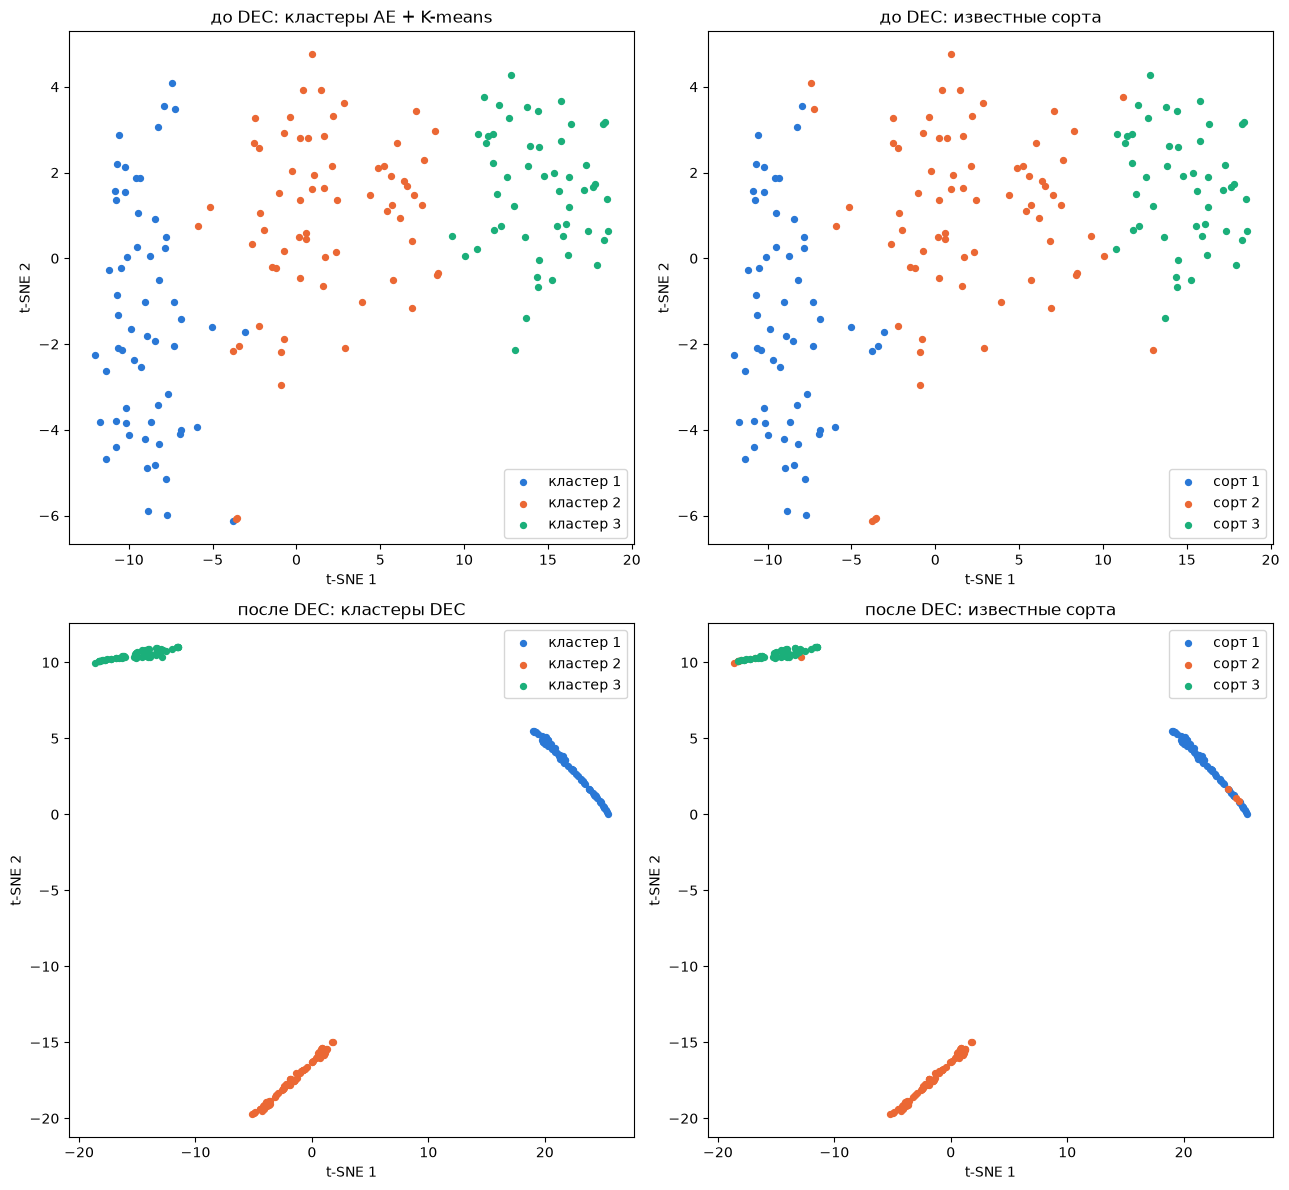

In [49]:
emb_ae = TSNE(n_components=2, perplexity=30, init='pca', random_state=RANDOM_STATE).fit_transform(Z_ae)
emb_dec = TSNE(n_components=2, perplexity=30, init='pca', random_state=RANDOM_STATE).fit_transform(Z_dec)
fig, axes = plt.subplots(2, 2, figsize=(13, 12))
panels = [(axes[0, 0], emb_ae, labels_ae, 'до DEC: кластеры AE + K-means', 'кластер'),
          (axes[0, 1], emb_ae, y_true.to_numpy(), 'до DEC: известные сорта', 'сорт'),
          (axes[1, 0], emb_dec, labels_dec, 'после DEC: кластеры DEC', 'кластер'),
          (axes[1, 1], emb_dec, y_true.to_numpy(), 'после DEC: известные сорта', 'сорт')]
for ax, emb, labels, title, word in panels:
    for c in np.unique(labels):
        ax.scatter(emb[labels == c, 0], emb[labels == c, 1], s=18, color=COLORS[c - 1], label=f'{word} {c}')
    ax.set_title(title)
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    ax.legend()
fig.tight_layout()
fig.savefig('Рисунки/tsne_латентное.png', dpi=200, bbox_inches='tight')
plt.show()

До уточнения (верхний ряд) в латентном пространстве видны три группы, которые соприкасаются; кластеры
автокодировщика + K-means в целом совпадают с ними, а расхождения с сортами — на стыках групп. После DEC (нижний ряд)
объекты каждого кластера стянуты в узкую плотную полосу, а кластеры далеко разнесены. Это согласуется с устройством
функции потерь DEC: целевое распределение P усиливает наибольшую $q_{ij}$ каждого объекта, и обучение сдвигает объект
к одному центру. При этом образцы сорта 2, отнесённые к кластерам 1 и 3, оказались внутри этих полос — DEC сделал
уверенными и ошибочные назначения. Поэтому чёткое разделение на картинке после DEC не доказывает качества
кластеризации; качество оценивается метриками в общем пространстве (п. 7.5).

### 7.7. Интерпретация групп DEC

In [50]:
centers_dec = pd.DataFrame(X_scaled, columns=X.columns).groupby(labels_dec).mean()
centers_dec_orig = pd.DataFrame(scaler.inverse_transform(centers_dec), columns=X.columns,
                                index=[f'кластер {c}' for c in centers_dec.index]).T
centers_dec_orig['среднее по всем'] = X.mean()
display(centers_dec_orig.round(3))
centers_dec_orig.to_csv('Результаты/центры_исходные_DEC.csv', encoding='utf-8')
for c, row in centers_dec.iterrows():
    print(f'DEC, кластер {c}: выше среднего —', ', '.join(row[row > 0.5].sort_values(ascending=False).index),
          '| ниже среднего —', ', '.join(row[row < -0.5].sort_values().index))
table_dec_km = pd.crosstab(pd.Series(labels_dec, name='DEC'), pd.Series(labels_km, name='K-means'))
table_dec_sort = pd.crosstab(pd.Series(labels_dec, name='DEC'), y_true.rename('сорт'))
display(table_dec_km)
display(table_dec_sort)
table_dec_km.to_csv('Результаты/сопряжённость_DEC_kmeans.csv', encoding='utf-8')
table_dec_sort.to_csv('Результаты/сопряжённость_DEC.csv', encoding='utf-8')

,кластер 1,кластер 2,кластер 3,среднее по всем
Alcohol,13.677,12.257,13.063,13.001
Malic_acid,1.998,1.954,3.142,2.336
Ash,2.466,2.236,2.399,2.367
Alcalinity_of_ash,17.463,20.385,20.798,19.495
Magnesium,107.968,91.279,99.855,99.742
Total_phenols,2.848,2.260,1.711,2.295
Flavanoids,3.003,2.124,0.826,2.029
Nonflavanoid_phenols,0.292,0.358,0.445,0.362
Proanthocyanins,1.922,1.696,1.101,1.591
Color_intensity,5.454,3.025,6.867,5.058


DEC, кластер 1: выше среднего — Proline, Flavanoids, Total_phenols, Alcohol, OD280_OD315, Proanthocyanins, Magnesium | ниже среднего — Alcalinity_of_ash, Nonflavanoid_phenols
DEC, кластер 2: выше среднего —  | ниже среднего — Alcohol, Color_intensity, Proline, Magnesium
DEC, кластер 3: выше среднего — Color_intensity, Malic_acid, Nonflavanoid_phenols | ниже среднего — OD280_OD315, Flavanoids, Hue, Total_phenols, Proanthocyanins


K-means,1,2,3
DEC,,,
1,62,0,0
2,0,60,1
3,0,5,50


сорт,1,2,3
DEC,,,
1,59,3,0
2,0,61,0
3,0,7,48


Кластер 1 DEC полностью совпадает с кластером 1 K-means (62 объекта, те же центры), кластеры 2 и 3 отличаются
шестью объектами: 5 объектов кластера 2 K-means DEC отнёс к кластеру 3 и 1 объект — наоборот. Профили групп те же,
что у K-means (п. 6.2): кластер 1 — высокие Proline, Flavanoids, Total_phenols, Alcohol; кластер 2 — низкие Alcohol,
Color_intensity, Proline и Magnesium; кластер 3 — высокие Color_intensity, Malic_acid, Nonflavanoid_phenols и низкие
OD280_OD315, Flavanoids, Hue, Total_phenols, Proanthocyanins. Новых групп глубокая кластеризация не выделила.
Расхождений с сортами у DEC 10 (3 образца сорта 2 в кластере 1 и 7 в кластере 3), у K-means — 6.

### 7.8. Целесообразность глубокой кластеризации для набора Wine
Для набора Wine глубокая кластеризация нецелесообразна:
1. Качество не выше, чем у простых методов: K-means на стандартизованных признаках лучше по всем внутренним метрикам
   (силуэт 0,285 против 0,279 у автокодировщика + K-means и 0,274 у DEC) и по согласию с сортами (ARI 0,897 против
   0,848 и 0,837); EM-алгоритм с диагональными ковариациями согласуется с сортами ещё лучше (ARI 0,915).
2. Результат сильно зависит от гиперпараметров: по 18 конфигурациям при k = 3 справочный ARI меняется от 0,375 до
   0,894, а силуэт, по которому выбор делается без меток, различает лучшие варианты лишь в третьем знаке
   (0,272–0,279).
3. Данных мало: 178 объектов (для обучения автокодировщика — 142) позволяют обучить только очень маленькую сеть
   (288 параметров при `latent_dim` = 3).
4. Затраты и сложность выше: 18 обучений сети по 300 эпох и 1000 итераций DEC против нескольких запусков K-means;
   латентные признаки не имеют химического смысла, и интерпретировать группы всё равно приходится по исходным
   признакам (п. 7.7).

Метод DEC предлагался и проверялся на наборах изображений и текстов из десятков и сотен тысяч объектов. В Wine три
группы видны уже в исходных признаках и в линейной проекции PCA, и классические методы выделяют их не хуже.

## Выводы
1. Набор Wine — 178 образцов, 13 числовых признаков химического состава, пропусков и дубликатов нет. Нормальность
   отвергается для 12 признаков из 13 (тест Шапиро–Уилка); у Malic_acid, Magnesium, Color_intensity и Proline
   правосторонняя асимметрия, у Flavanoids и OD280_OD315 — по два максимума. Выбросы (10 объектов по |z| > 3)
   оставлены: их удаление почти не меняет разбиение (ARI 0,981). Главную структуру данных задают Flavanoids,
   Total_phenols, Color_intensity, OD280_OD315, Proline и Alcohol.
2. Стандартизация необходима: без неё на Proline приходится 99,77 % суммы дисперсий, и K-means делит данные только по
   Proline (ARI с разбиением по одному Proline = 1,0). Диаграммы рассеяния и проекция PCA показывают три компактные
   группы без пустых промежутков между ними.
3. Метод локтя, силуэт (0,285 для K-means и 0,277 для метода Уорда) и дендрограмма (наибольший скачок высоты при
   переходе от трёх кластеров к двум) дают k = 3.
4. K-means лучше метода Уорда по внутренним (силуэт 0,285 и 0,277, CH 70,9 и 67,6, DB 1,389 и 1,419) и по внешним
   метрикам (ARI 0,897 и 0,790, Жаккар 0,872 и 0,755, NMI 0,876 и 0,786). Кластеры K-means почти совпадают с
   сортами: 6 расхождений из 178.
5. У K-means все внутренние метрики лучшие при k = 3. DBSCAN в 13-мерном пространстве не выделяет трёх групп без
   большой доли шума (три кластера — только при шуме от 18 %); выбранный вариант даёт два кластера и 16,9 % шума
   (ARI 0,421).
6. Группы по данным: кластер 1 — высокие Proline, Flavanoids, Total_phenols и Alcohol; кластер 2 — низкие Alcohol,
   Color_intensity и Proline; кластер 3 — высокие Color_intensity и Malic_acid, низкие Flavanoids, Hue и OD280_OD315.
   Методы согласуются (ARI 0,853, совпадение 169 из 178), группы K-means устойчивы (ARI на подвыборках в среднем
   0,974, у метода Уорда 0,858).
7. Глубокая кластеризация (автокодировщик 13 → 8 → 5 → 8 → 13 + K-means, уточнение DEC) выделила те же три группы,
   но не превзошла K-means (силуэт 0,279 и 0,274, ARI 0,848 и 0,837); для 178 объектов она нецелесообразна.

In [51]:
for name in final.index:
    summary['итог_' + name] = {m: round(float(final.loc[name, m]), 6) for m in final.columns}
with open('Результаты/сводка.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=1)
print('Сохранено чисел в сводке:', len(summary))

Сохранено чисел в сводке: 49


Все таблицы сохранены в папку `Результаты/` (csv), рисунки — в `Рисунки/` (png), основные числа — в
`Результаты/сводка.json`; по ним составлен отчёт.